In [1]:
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge
import geopandas as gpd
from shapely.geometry import Point, Polygon
import math
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import seaborn as sns
from path_config import PathConfig

In [2]:
paths = PathConfig()

In [3]:
dl = pd.read_excel(paths.dl_path, sheet_name="Series Formatted Data")

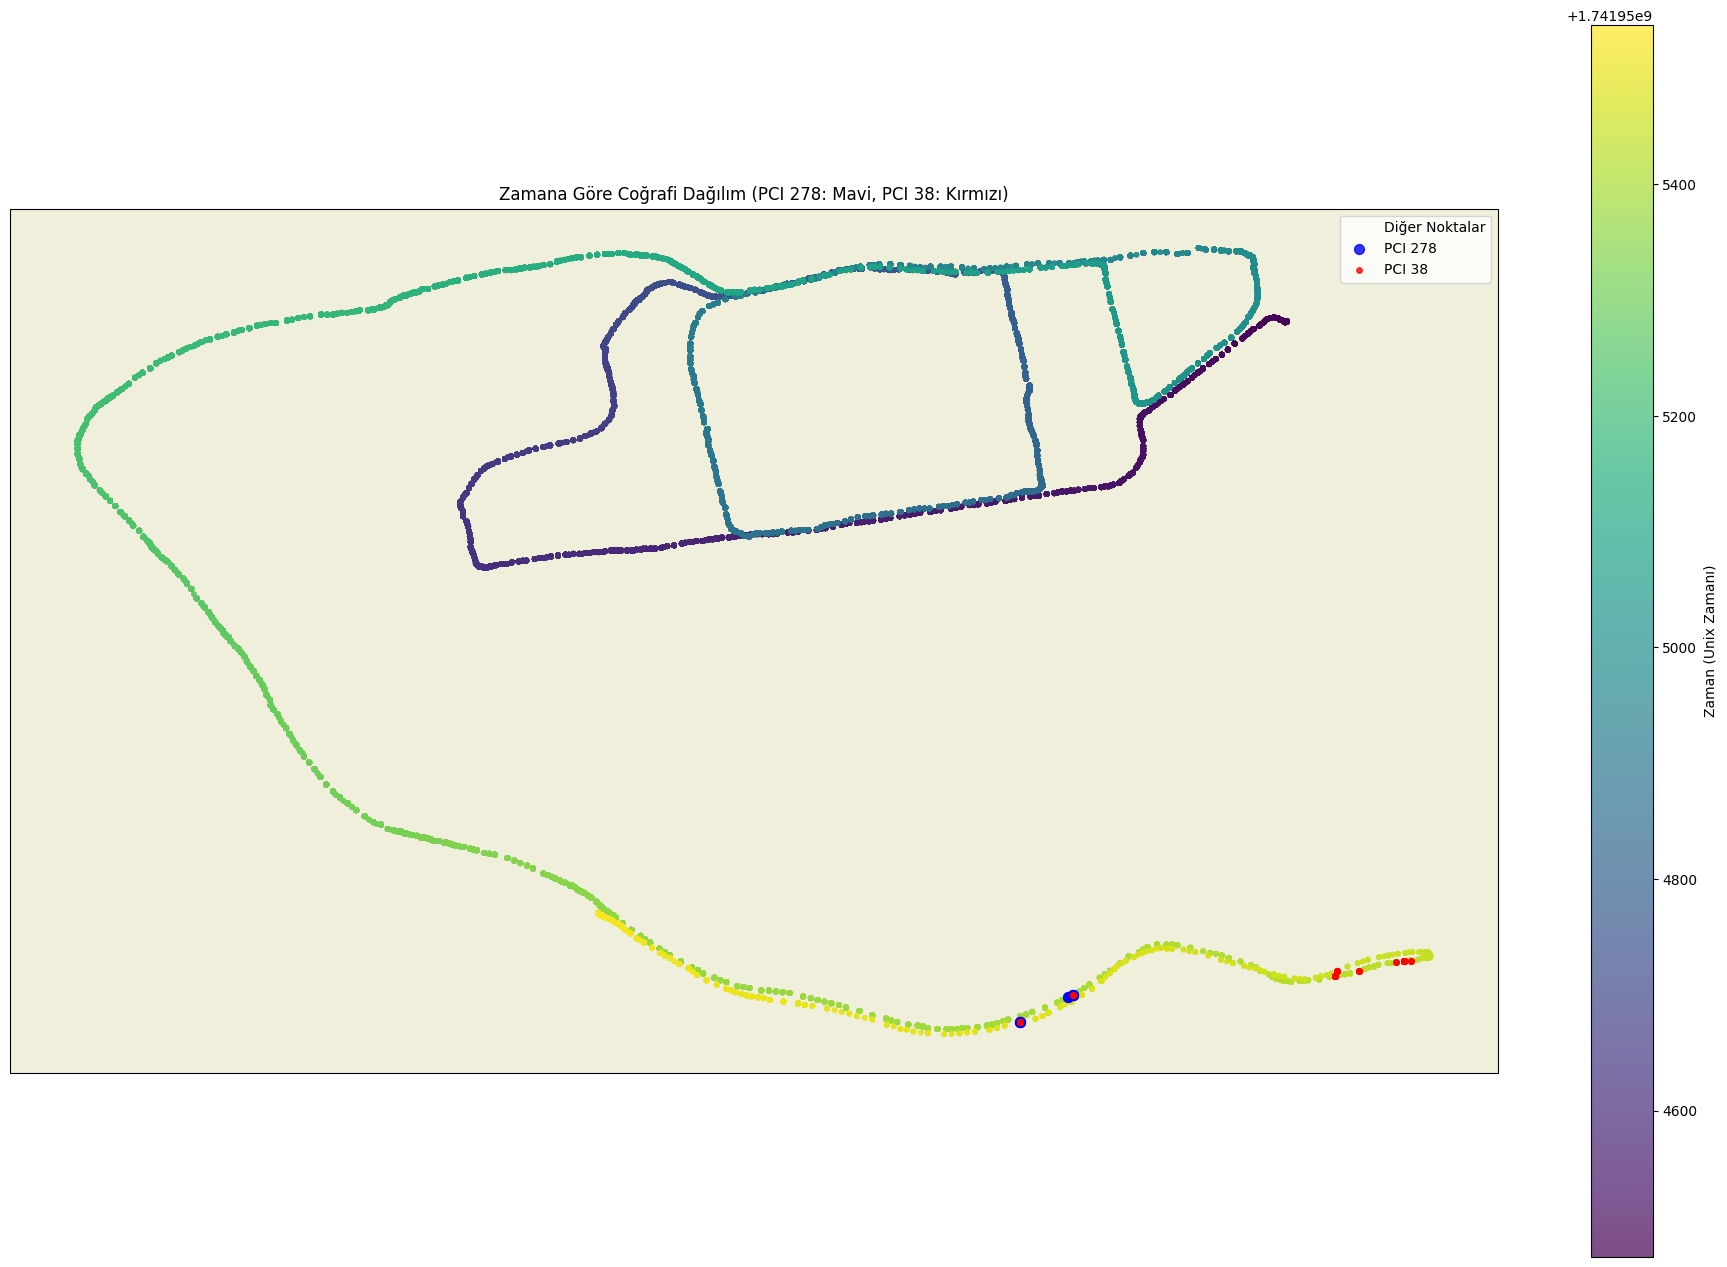

In [4]:
# Zamanı normalize ederek renk skalasına dönüştür
time_numeric = pd.to_datetime(dl["Time"]).astype(int) / 10**9

# Harita oluştur
fig = plt.figure(figsize=(24, 16))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)

# Ana scatter plot (zaman skalalı renkler)
sc = ax.scatter(
    dl["Longitude"],
    dl["Latitude"],
    c=time_numeric,
    cmap="viridis",
    s=10,
    alpha=0.7,
    label="Diğer Noktalar"
)

# PCI değeri 278 olanları filtrele ve mavi renkte göster
mask_278 = dl["NR_UE_PCI_0"] == 278
ax.scatter(
    dl[mask_278]["Longitude"],
    dl[mask_278]["Latitude"],
    color="blue",
    s=50,
    alpha=0.8,
    label="PCI 278"
)

# PCI değeri 38 olanları filtrele ve kırmızı renkte göster
mask_38 = dl["NR_UE_PCI_0"] == 38
ax.scatter(
    dl[mask_38]["Longitude"],
    dl[mask_38]["Latitude"],
    color="red",
    s=15,
    alpha=0.8,
    label="PCI 38"
)

plt.colorbar(sc, label="Zaman (Unix Zamanı)")
ax.set_title("Zamana Göre Coğrafi Dağılım (PCI 278: Mavi, PCI 38: Kırmızı)")
ax.legend()

plt.show()


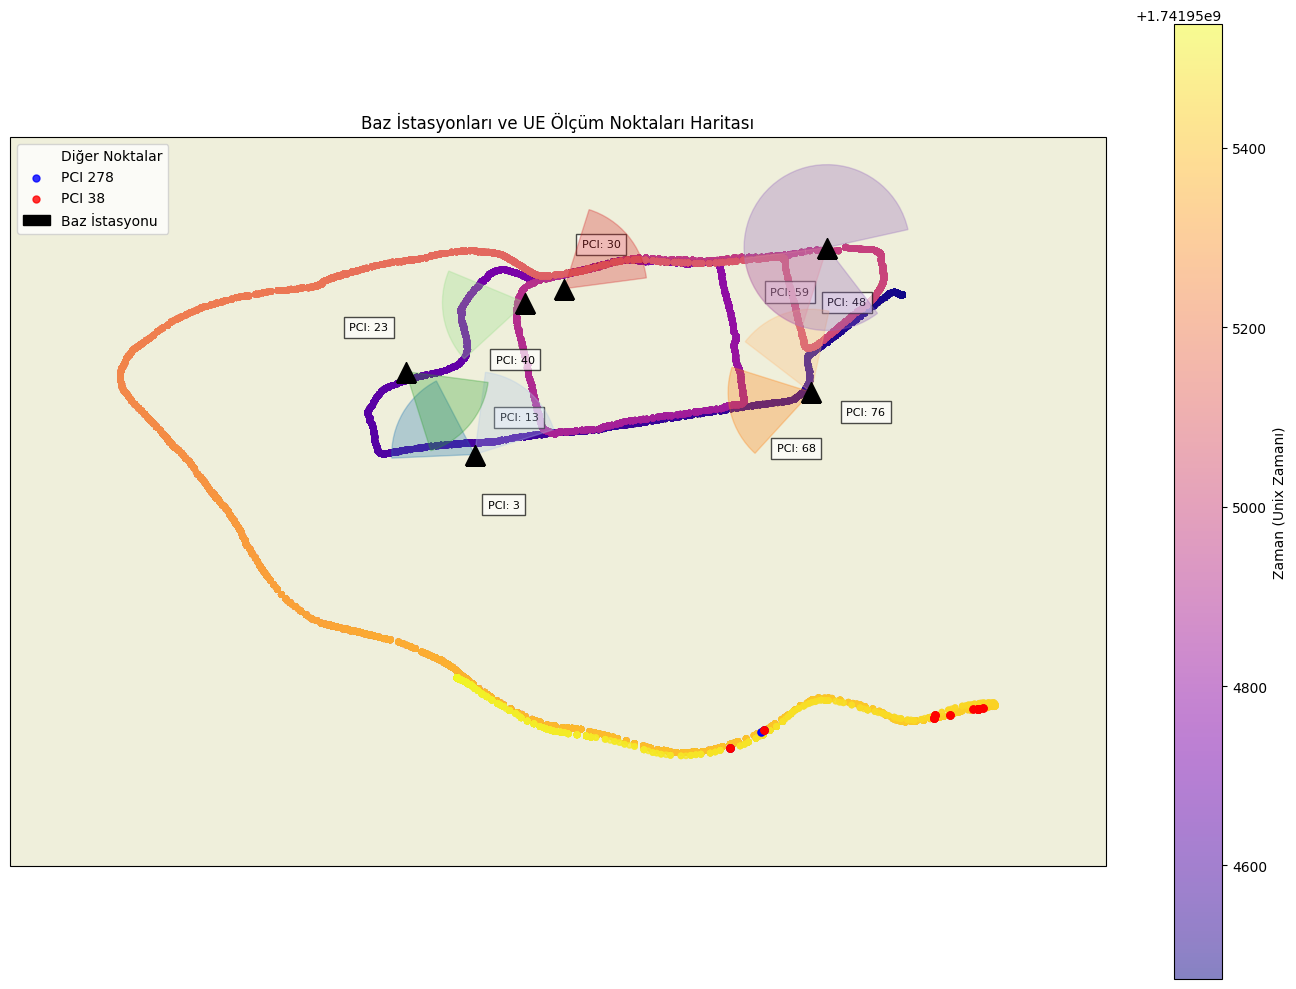

In [5]:

bs_df = pd.read_excel(paths.Hucre_Bilgileri, sheet_name="Hücre tablosu")

# Zamanı normalize ederek renk skalasına dönüştür
time_numeric = pd.to_datetime(dl["Time"]).astype(int) / 10**9

# Harita oluştur
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)

# Haritayı ölçeklendir ve baz istasyonları etrafına odakla
buffer = 0.002  # Yaklaşık 200 metre buffer
min_lon = min(bs_df["Longitude"].min(), dl["Longitude"].min()) - buffer
max_lon = max(bs_df["Longitude"].max(), dl["Longitude"].max()) + buffer
min_lat = min(bs_df["Latitude"].min(), dl["Latitude"].min()) - buffer
max_lat = max(bs_df["Latitude"].max(), dl["Latitude"].max()) + buffer

ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

# Ana scatter plot (zaman skalalı renkler)
sc = ax.scatter(
    dl["Longitude"],
    dl["Latitude"],
    c=time_numeric,
    cmap="plasma",
    s=15,
    alpha=0.5,
    label="Diğer Noktalar"
)

# PCI değeri 278 olanları filtrele ve mavi renkte göster
mask_278 = dl["NR_UE_PCI_0"] == 278
ax.scatter(
    dl[mask_278]["Longitude"],
    dl[mask_278]["Latitude"],
    color="blue",
    s=25,
    alpha=0.8,
    label="PCI 278"
)

# PCI değeri 38 olanları filtrele ve kırmızı renkte göster
mask_38 = dl["NR_UE_PCI_0"] == 38
ax.scatter(
    dl[mask_38]["Longitude"],
    dl[mask_38]["Latitude"],
    color="red",
    s=25,
    alpha=0.8,
    label="PCI 38"
)

# PCI renk haritası oluştur - baz istasyonlarını temsil etmek için
pci_cmap = plt.cm.tab20(np.linspace(0, 1, 20))
pci_colors = dict()

# Baz istasyonlarını ekle
station_groups = bs_df.groupby(["Latitude", "Longitude"])
for (lat, lon), group in station_groups:
    # Baz istasyonu konumunu işaretle
    ax.plot(lon, lat, 'k^', markersize=14, markeredgecolor='black', zorder=10)
    
    # Her sektör için kapsama alanını çiz
    for _, row in group.iterrows():
        azimuth = row["Azimuth [°]"]
        beamwidth = row["Horizontal Beamwidth [°]"]
        pci = row["PCI "]
        
        # Her PCI için tutarlı renk ataması yap
        if pci not in pci_colors:
            pci_colors[pci] = pci_cmap[len(pci_colors) % 20]
        
        # Kapsama alanını dilim (wedge) olarak göster
        # Azimuth açısı, beamwidth ve kapsama mesafesi
        start_angle = (azimuth - beamwidth/2) % 360
        end_angle = (azimuth + beamwidth/2) % 360
        
        # Açıları matematik açısından (saat yönünün tersi) coğrafi açıya (kuzeyden saat yönünde) dönüştür
        start_angle = (90 - start_angle) % 360
        end_angle = (90 - end_angle) % 360
        if start_angle > end_angle:
            start_angle, end_angle = end_angle, start_angle
            
        # Kapsama mesafesi - güç ve yükseklik baz alınarak basit bir tahmin
        # Gerçek kapsama alanı için daha karmaşık propagasyon modelleri kullanılmalıdır
        coverage_radius = 0.0015  # Yaklaşık 150 metre
        
        wedge = Wedge((lon, lat), coverage_radius, start_angle, end_angle, 
                     alpha=0.3, color=pci_colors[pci], zorder=5)
        ax.add_patch(wedge)
        
        # PCI değerini göster
        # Yön vektörünün ortasında PCI değerini göster
        middle_angle_rad = np.radians((start_angle + end_angle) / 2)
        # Kartezyen koordinatlara dönüştür (matematik açısı olduğundan sin ve cos yer değiştirir)
        dx = np.sin(middle_angle_rad) * coverage_radius * 0.7
        dy = np.cos(middle_angle_rad) * coverage_radius * 0.7
        ax.text(lon + dx, lat + dy, f"PCI: {int(pci)}", fontsize=8, 
                ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7))

# Renk ölçeği ekle
cbar = plt.colorbar(sc, label="Zaman (Unix Zamanı)")

ax.set_title("Baz İstasyonları ve UE Ölçüm Noktaları Haritası")

# Lejant oluştur
handles, labels = ax.get_legend_handles_labels()

# Baz istasyonu için lejant ekle
station_marker = mpatches.Patch(color='black', label='Baz İstasyonu')
handles.append(station_marker)
labels.append('Baz İstasyonu')

ax.legend(handles=handles, labels=labels, loc='upper left')

plt.tight_layout()
plt.show()

In [6]:
# 1. Baz İstasyonları için GeoDataFrame oluştur
geometry = [Point(xy) for xy in zip(bs_df["Longitude"], bs_df["Latitude"])]
base_stations_gdf = gpd.GeoDataFrame(bs_df, geometry=geometry, crs="EPSG:4326")

# Baz istasyonlarını grupla (aynı konumdaki istasyonları birleştir)
base_stations_grouped = base_stations_gdf.dissolve(by=["Latitude", "Longitude"]).reset_index()
base_stations_grouped["type"] = "base_station"

# 2. Hücre sektörleri için GeoDataFrame oluştur
sectors_list = []

for _, row in bs_df.iterrows():
    lat = row["Latitude"]
    lon = row["Longitude"]
    azimuth = row["Azimuth [°]"]
    beamwidth = row["Horizontal Beamwidth [°]"]
    pci = row["PCI "]
    cell_name = row["Cell Name"]
    sector = row["Sector "]
    kabinet = row["Kabinet"]
    height = row["Height [m]"]
    power = row["Power [W]"]
    
    # Kapsama mesafesini güç ve yüksliğe göre ayarla (basit bir model)
    # Gerçek uygulamada daha karmaşık propagasyon modelleri kullanılır
    coverage_distance = 1000  # metre
    coverage_distance = coverage_distance * (power/200)**0.5 * (height/10)**0.3
    
    # Dilim (wedge) oluştur
    start_angle = (azimuth - beamwidth/2) % 360
    end_angle = (azimuth + beamwidth/2) % 360
    
    # Açıları radian'a çevir
    start_angle_rad = math.radians(start_angle)
    end_angle_rad = math.radians(end_angle)
    
    # Büyük bir çokgen oluşturmak için açıları küçük adımlara böl
    num_points = 20
    if start_angle > end_angle:
        angles = np.linspace(start_angle_rad, end_angle_rad + 2*np.pi, num_points)
    else:
        angles = np.linspace(start_angle_rad, end_angle_rad, num_points)
    
    # WGS84 (EPSG:4326) koordinat sisteminde açısal mesafeyi metreye çevir
    # 1 derece yaklaşık 111 km (ekvator)
    # Boylam için enlem faktörü: cos(lat * pi/180)
    lat_factor = 111000  # 1 derece enlem yaklaşık 111 km
    lon_factor = 111000 * math.cos(math.radians(lat))  # Boylam faktörü
    
    # Merkez nokta
    source_point = Point(lon, lat)
    
    # Dilim çokgenini oluştur
    # Başlangıç noktası: baz istasyonu konumu
    polygon_points = [source_point]
    
    # Dilim kenarları boyunca noktalar
    for angle in angles:
        # Açıdan x ve y bileşenlerini hesapla (kuzeyden başlayarak saat yönünde)
        dx = math.sin(angle) * coverage_distance / lon_factor
        dy = math.cos(angle) * coverage_distance / lat_factor
        
        # Yeni koordinatlar
        new_lon = lon + dx
        new_lat = lat + dy
        
        polygon_points.append(Point(new_lon, new_lat))
    
    # Çokgeni kapat
    polygon_points.append(source_point)
    
    # Koordinatları çokgene dönüştür
    coords = [(p.x, p.y) for p in polygon_points]
    sector_polygon = Polygon(coords)
    
    # Sektör verilerini ekle
    sectors_list.append({
        "geometry": sector_polygon,
        "Kabinet": kabinet,
        "Sector": sector,
        "CellName": cell_name,
        "PCI": pci,
        "Azimuth": azimuth,
        "Beamwidth": beamwidth,
        "Height": height,
        "Power": power,
        "type": "sector"
    })

# Sektörler için GeoDataFrame oluştur
sectors_gdf = gpd.GeoDataFrame(sectors_list, crs="EPSG:4326")

# 3. UE noktaları için (varsa) GeoDataFrame oluştur
# Burada dl DataFrame'inin var olduğunu ve gerekli sütunları içerdiğini varsayıyoruz
# Eğer dl DataFrame'i tanımlı değilse, bu kısmı atlayabilirsiniz
try:
    geometry = [Point(xy) for xy in zip(dl["Longitude"], dl["Latitude"])]
    ue_gdf = gpd.GeoDataFrame(dl, geometry=geometry, crs="EPSG:4326")
    
    # PCI 38 ve 278 için filtreleme
    ue_pci_38_gdf = ue_gdf[ue_gdf["NR_UE_PCI_0"] == 38].copy()
    ue_pci_38_gdf["PCIType"] = "PCI 38"
    
    ue_pci_278_gdf = ue_gdf[ue_gdf["NR_UE_PCI_0"] == 278].copy()
    ue_pci_278_gdf["PCIType"] = "PCI 278"
    
    ue_other_gdf = ue_gdf[~ue_gdf["NR_UE_PCI_0"].isin([38, 278])].copy()
    ue_other_gdf["PCIType"] = "Other PCI"
    
    # Tüm UE verilerini tek bir GeoDataFrame'de birleştir
    ue_combined_gdf = pd.concat([ue_pci_38_gdf, ue_pci_278_gdf, ue_other_gdf])
    ue_combined_gdf["type"] = "ue_point"
    
    has_ue_data = True
except NameError:
    print("UE veri çerçevesi (dl) bulunamadı, sadece baz istasyonları ve sektörler kaydedilecek.")
    has_ue_data = False

# 4. Tüm katmanları tek bir GeoPackage'a kaydet (QGIS'te kullanım için idealdir)
if has_ue_data:
    # Tüm GeoDataFrame'leri bir liste içinde birleştir
    all_layers = {
        'base_stations': base_stations_gdf,
        'sectors': sectors_gdf,
        'ue_points': ue_combined_gdf
    }
else:
    all_layers = {
        'base_stations': base_stations_gdf,
        'sectors': sectors_gdf
    }

# GeoPackage'a kaydet
for layer_name, gdf in all_layers.items():
    gdf.to_file(paths._processed_harita_dir / "telecom_network.gpkg", layer=layer_name, driver="GPKG")


print("GeoPackage dosyası: telecom_network.gpkg")

GeoPackage dosyası: telecom_network.gpkg


In [7]:
def oklidian_distance(lat1, lon1, lat2, lon2):
    """
    İki nokta arasındaki Öklidyen mesafeyi hesaplar.
    :param lat1: İlk noktanın enlemi
    :param lon1: İlk noktanın boylamı
    :param lat2: İkinci noktanın enlemi
    :param lon2: İkinci noktanın boylamı
    :return: Mesafe (metre cinsinden)
    """
    return math.sqrt((lat1 - lat2) ** 2 + (lon1 - lon2) ** 2) * 111  # Yaklaşık 111 km = 1° enlem/boylam farkı

In [8]:
def calculate_distance(row, pci_col):
    """Dinamik PCI kolon adı ile mesafe hesaplama"""
    try:
        current_pci = row[pci_col]
        if pd.isna(current_pci):
            return np.nan
            
        # PCI eşleşmesini bul
        pci_mask = bs_df["PCI "] == current_pci
        
        if not pci_mask.any():
            return np.nan
            
        # BS koordinatlarını al
        bs_lat = bs_df.loc[pci_mask, "Latitude"].iloc[0]
        bs_lon = bs_df.loc[pci_mask, "Longitude"].iloc[0]
        
        return oklidian_distance(row["Latitude"], row["Longitude"], bs_lat, bs_lon)
        
    except (IndexError, KeyError, TypeError):
        return np.nan

# Tüm PCI kolonlarını listele
pci_columns = [
    "NR_UE_PCI_0",
    "NR_UE_Nbr_PCI_0",
    "NR_UE_Nbr_PCI_1", 
    "NR_UE_Nbr_PCI_2",
    "NR_UE_Nbr_PCI_3",
    "NR_UE_Nbr_PCI_4"
]

# Her PCI kolonu için mesafe hesapla
for col in pci_columns:
    new_col_name = f"distance_to_{col.lower()[6:]}"
    dl[new_col_name] = dl.apply(lambda row: calculate_distance(row, col), axis=1)

In [9]:
bs_df["max_coverage"] = bs_df["PCI "].apply(lambda x: max(dl[dl["NR_UE_PCI_0"] == x]["distance_to_pci_0"].max(), dl[dl["NR_UE_Nbr_PCI_0"] == x]["distance_to_nbr_pci_0"].max(), dl[dl["NR_UE_Nbr_PCI_1"] == x]["distance_to_nbr_pci_1"].max(), dl[dl["NR_UE_Nbr_PCI_2"] == x]["distance_to_nbr_pci_2"].max(), dl[dl["NR_UE_Nbr_PCI_3"] == x]["distance_to_nbr_pci_3"].max(), dl[dl["NR_UE_Nbr_PCI_4"] == x]["distance_to_nbr_pci_4"].max()))

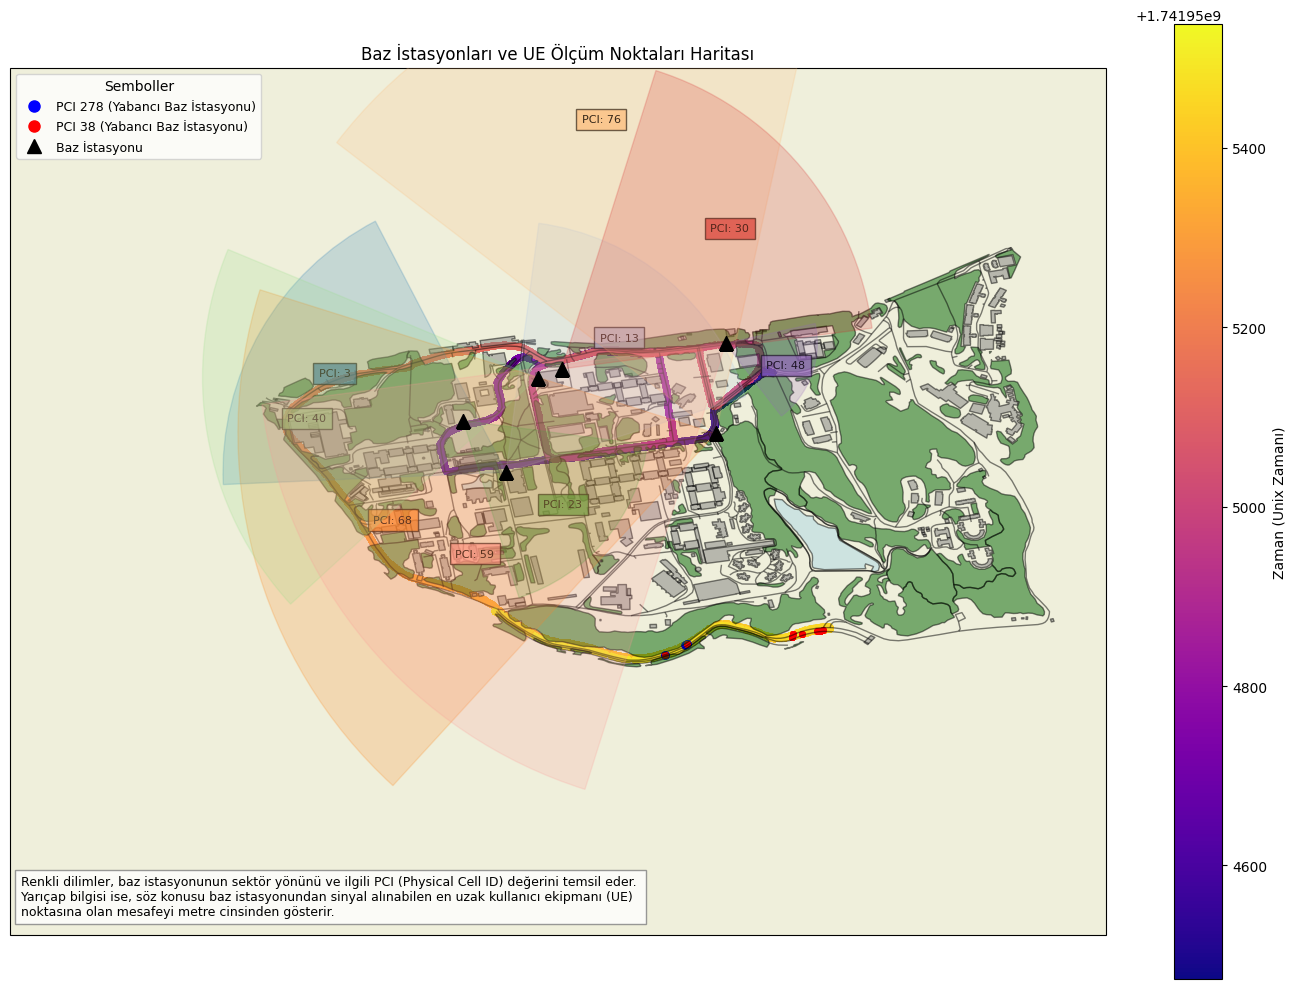

In [10]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.colors import LinearSegmentedColormap
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature
import matplotlib.patches as mpatches
import matplotlib.lines as mlines



time_numeric = pd.to_datetime(dl["Time"]).astype(int) / 10**9

# Harita oluştur
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)

# ITU binalarının shapefile'ını ekle
reader = shpreader.Reader(paths.build_path)
buildings = ShapelyFeature(reader.geometries(), ccrs.PlateCarree(),
                           edgecolor='black', facecolor='gray', alpha=0.5)
ax.add_feature(buildings)
reader = shpreader.Reader(paths.vege_path)
vegetations = ShapelyFeature(reader.geometries(), ccrs.PlateCarree(),
                           edgecolor='black', facecolor='DarkGreen', alpha=0.5)
ax.add_feature(vegetations)

reader = shpreader.Reader(paths.wathers_path)
wathers = ShapelyFeature(reader.geometries(), ccrs.PlateCarree(),
                           edgecolor='black', facecolor='LightBlue', alpha=0.5)
ax.add_feature(wathers)

reader = shpreader.Reader(paths.roads_path)
roads = ShapelyFeature(reader.geometries(), ccrs.PlateCarree(),
                           edgecolor='black', facecolor='none', alpha=0.5)
ax.add_feature(roads)

# Haritayı ölçeklendir ve baz istasyonları etrafına odakla
buffer = 0.008  # Yaklaşık 500 metre buffer
min_lon = min(bs_df["Longitude"].min(), dl["Longitude"].min()) - buffer
max_lon = max(bs_df["Longitude"].max(), dl["Longitude"].max()) + buffer
min_lat = min(bs_df["Latitude"].min(), dl["Latitude"].min()) - buffer
max_lat = max(bs_df["Latitude"].max(), dl["Latitude"].max()) + buffer

ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

# Ana scatter plot (zaman skalalı renkler)
sc = ax.scatter(
    dl["Longitude"],
    dl["Latitude"],
    c=time_numeric,
    cmap="plasma",
    s=15,
)

# PCI değeri 278 olanları filtrele ve mavi renkte göster
mask_278 = dl["NR_UE_PCI_0"] == 278
ax.scatter(
    dl[mask_278]["Longitude"],
    dl[mask_278]["Latitude"],
    color="blue",
    s=25,
    label="Yabancı Baz istasyonu PCI 278"
)

# PCI değeri 38 olanları filtrele ve kırmızı renkte göster
mask_38 = dl["NR_UE_PCI_0"] == 38
ax.scatter(
    dl[mask_38]["Longitude"],
    dl[mask_38]["Latitude"],
    color="red",
    s=15,
    label="Yabancı Baz istasyonu PCI 38"
)



# PCI renk haritası oluştur - baz istasyonlarını temsil etmek için
pci_cmap = plt.cm.tab20(np.linspace(0, 1, 20))
pci_colors = dict()

# Baz istasyonlarını ekle
station_groups = bs_df.groupby(["Latitude", "Longitude"])
for (lat, lon), group in station_groups:
    # Baz istasyonu konumunu işaretle
    ax.plot(lon, lat, 'k^', markersize=10, markeredgecolor='Black', zorder=10)
    
    # Her sektör için kapsama alanını çiz
    for _, row in group.iterrows():
        azimuth = row["Azimuth [°]"]
        beamwidth = row["Horizontal Beamwidth [°]"]
        pci = row["PCI "]
        
        # Her PCI için tutarlı renk ataması yap
        if pci not in pci_colors:
            pci_colors[pci] = pci_cmap[len(pci_colors) % 20]
        
        # Kapsama alanını dilim (wedge) olarak göster
        # 1. Azimuth'u matematiksel açıya çevir (kuzey=90°, saat yönünün tersi)
        math_angle = (90 - azimuth) % 360
        
        # 2. Beamwidth'i matematiksel açı sisteminde uygula
        start_angle = (math_angle - beamwidth/2) % 360
        end_angle = (math_angle + beamwidth/2) % 360
        
        # 3. Kapsama mesafesi
        coverage_radius = row["max_coverage"] / 100  # Ölçeği ayarlayın
        
        wedge = Wedge((lon, lat), coverage_radius, start_angle, end_angle, 
                    alpha=0.2, color=pci_colors[pci], zorder=5)
        ax.add_patch(wedge)
        
        # PCI değerini göster (MERKEZ AÇISINI KULLAN)
        middle_angle_rad = np.radians(math_angle)  
        
        # 4. dx/dy hesaplamasını düzelt (cos(theta) x, sin(theta) y)
        dx = np.cos(middle_angle_rad) * coverage_radius * 0.7  
        dy = np.sin(middle_angle_rad) * coverage_radius * 0.7   
        
        ax.text(lon + dx, lat + dy, f"PCI: {int(pci)}", fontsize=8, 
                ha='center', va='center', bbox=dict(facecolor=pci_colors[pci], alpha=0.7))

# Renk ölçeği ekle
cbar = plt.colorbar(sc, label="Zaman (Unix Zamanı)")

ax.set_title("Baz İstasyonları ve UE Ölçüm Noktaları Haritası")

# Lejant öğeleri
handles = []

# PCI 278 için mavi scatter sembolü
pci278_marker = mlines.Line2D([], [], color='blue', marker='o', linestyle='None',
                              markersize=8, label='PCI 278 (Yabancı Baz İstasyonu)')
handles.append(pci278_marker)

# PCI 38 için kırmızı scatter sembolü
pci38_marker = mlines.Line2D([], [], color='red', marker='o', linestyle='None',
                             markersize=8, label='PCI 38 (Yabancı Baz İstasyonu)')
handles.append(pci38_marker)

# Baz istasyonu üçgen marker'ı
station_marker = mlines.Line2D([], [], color='black', marker='^', linestyle='None',
                               markersize=10, label='Baz İstasyonu')
handles.append(station_marker)

# Scatter plot zaman renk skalası için otomatik etiket ekleniyor (cbar zaten var)
# İstersen özel bir renk noktası için açıklama da ekleyebiliriz.

# Lejantı haritaya yerleştir
ax.legend(handles=handles, loc='upper left', title='Semboller', fontsize=9, title_fontsize=10)

# PCI renk açıklaması kutusu - sol alt köşeye
ax.text(
    0.01, 0.02,  # Eksenin yüzde koordinatları (sol alt)
    "Renkli dilimler, baz istasyonunun sektör yönünü ve ilgili PCI (Physical Cell ID) değerini temsil eder. \nYarıçap bilgisi ise, söz konusu baz istasyonundan sinyal alınabilen en uzak kullanıcı ekipmanı (UE) \nnoktasına olan mesafeyi metre cinsinden gösterir.",
    transform=ax.transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'),
    ha='left',
    va='bottom'
)

plt.tight_layout()
plt.show()

C:\Users\osman\AppData\Local\Temp\ipykernel_4812\3257921945.py:17: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  time_ms = pd.to_datetime(dl["Time"]).view('int64') // 10**6


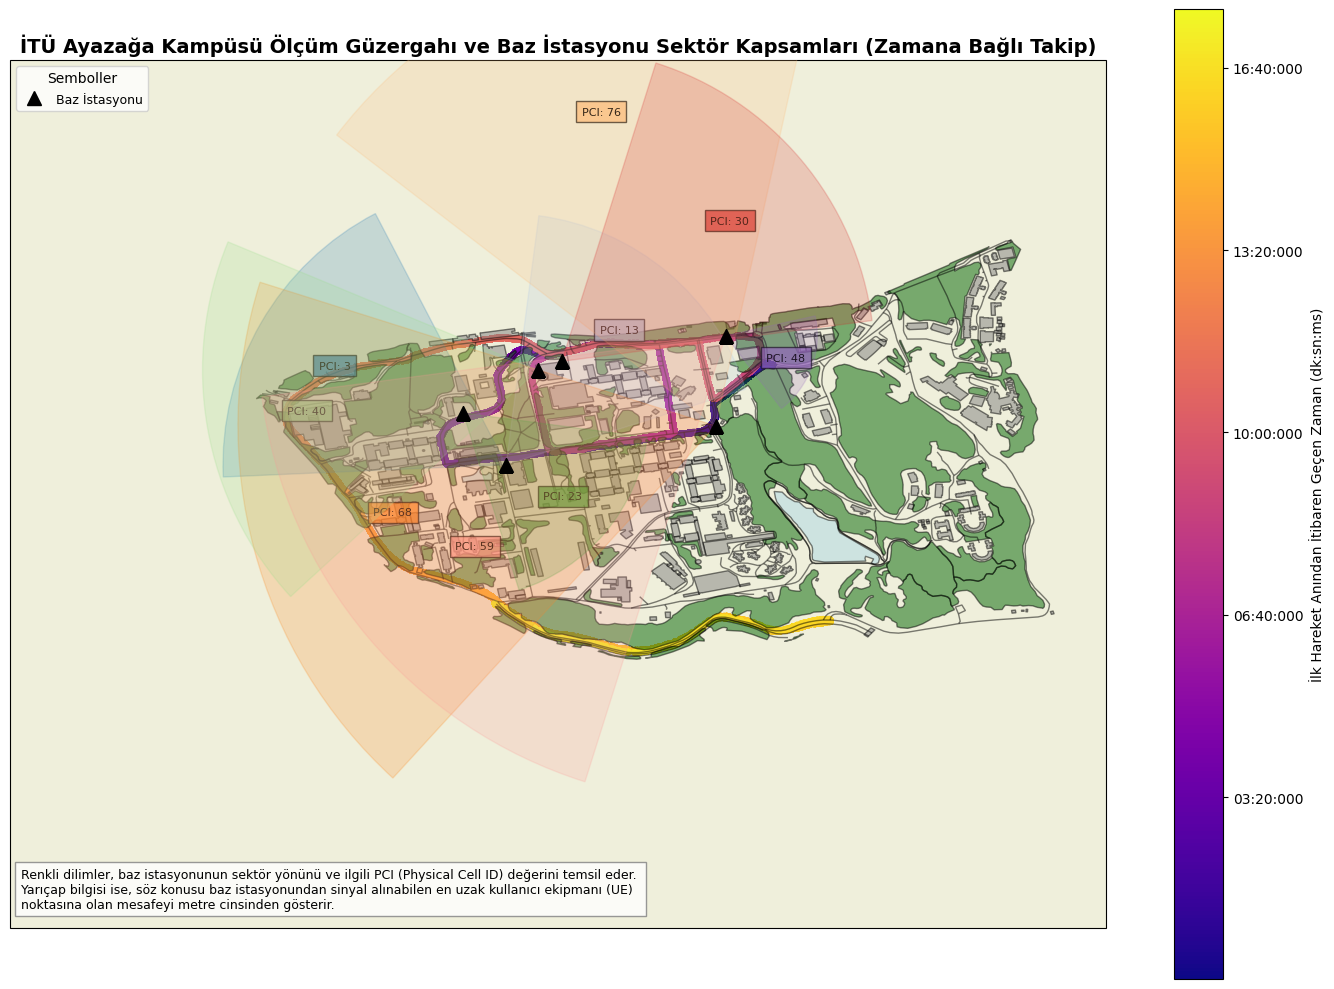

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.colors import LinearSegmentedColormap
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.patches import Wedge
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd

# Zamanı milisaniye cinsinden Unix formatına çevir
# 1. Zamanı milisaniye cinsinden al ve 0'dan başlat
time_ms = pd.to_datetime(dl["Time"]).view('int64') // 10**6
time_numeric = time_ms - time_ms.min()  # Başlangıcı sıfırla


# Harita oluştur
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_title(
    "İTÜ Ayazağa Kampüsü Ölçüm Güzergahı ve Baz İstasyonu Sektör Kapsamları (Zamana Bağlı Takip)",
    fontsize=14,
    fontweight='bold'
)

ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)

for path, color, alpha in [
    (paths.build_path, 'gray', 0.5),
    (paths.vege_path, 'DarkGreen', 0.5),
    (paths.wathers_path, 'LightBlue', 0.5),
    (paths.roads_path, 'none', 0.5)
]:
    reader = shpreader.Reader(path)
    feature = ShapelyFeature(reader.geometries(), ccrs.PlateCarree(),
                             edgecolor='black', facecolor=color, alpha=alpha)
    ax.add_feature(feature)

# Haritayı ölçeklendir
buffer = 0.008
min_lon = min(bs_df["Longitude"].min(), dl["Longitude"].min()) - buffer
max_lon = max(bs_df["Longitude"].max(), dl["Longitude"].max()) + buffer
min_lat = min(bs_df["Latitude"].min(), dl["Latitude"].min()) - buffer
max_lat = max(bs_df["Latitude"].max(), dl["Latitude"].max()) + buffer
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

# Ana scatter plot (renk: zaman)
sc = ax.scatter(
    dl["Longitude"],
    dl["Latitude"],
    c=time_numeric,
    cmap="plasma",
    s=15,
)

# PCI renk haritası oluştur
pci_cmap = plt.cm.tab20(np.linspace(0, 1, 20))
pci_colors = dict()

# Baz istasyonları ve sektörlerini çiz
station_groups = bs_df.groupby(["Latitude", "Longitude"])
for (lat, lon), group in station_groups:
    ax.plot(lon, lat, 'k^', markersize=10, markeredgecolor='Black', zorder=10)
    for _, row in group.iterrows():
        azimuth = row["Azimuth [°]"]
        beamwidth = row["Horizontal Beamwidth [°]"]
        pci = row["PCI "]
        
        if pci not in pci_colors:
            pci_colors[pci] = pci_cmap[len(pci_colors) % 20]
        
        math_angle = (90 - azimuth) % 360
        start_angle = (math_angle - beamwidth / 2) % 360
        end_angle = (math_angle + beamwidth / 2) % 360
        coverage_radius = row["max_coverage"] / 100
        
        wedge = Wedge((lon, lat), coverage_radius, start_angle, end_angle,
                      alpha=0.2, color=pci_colors[pci], zorder=5)
        ax.add_patch(wedge)
        
        middle_angle_rad = np.radians(math_angle)
        dx = np.cos(middle_angle_rad) * coverage_radius * 0.7
        dy = np.sin(middle_angle_rad) * coverage_radius * 0.7
        
        ax.text(lon + dx, lat + dy, f"PCI: {int(pci)}", fontsize=8,
                ha='center', va='center', bbox=dict(facecolor=pci_colors[pci], alpha=0.7))

# 📌 Zaman biçimlendirmesi: dakika:saniye:milisaniye
def format_time_mms(x, pos=None):
    ms_total = int(x)
    minutes = (ms_total // 60000) % 60
    seconds = (ms_total // 1000) % 60
    milliseconds = ms_total % 1000
    return f"{minutes:02}:{seconds:02}:{milliseconds:03}"

# Renk çubuğu (colorbar)
cbar = plt.colorbar(sc, label="İlk Hareket Anından İtibaren Geçen Zaman (dk:sn:ms)")
cbar.ax.yaxis.set_major_formatter(FuncFormatter(format_time_mms))

# Lejant
station_marker = mlines.Line2D([], [], color='black', marker='^', linestyle='None',
                               markersize=10, label='Baz İstasyonu')
ax.legend(handles=[station_marker], loc='upper left', title='Semboller', fontsize=9, title_fontsize=10)

# Açıklama kutusu (PCI sektörü)
ax.text(
    0.01, 0.02,
    "Renkli dilimler, baz istasyonunun sektör yönünü ve ilgili PCI (Physical Cell ID) değerini temsil eder. \n"
    "Yarıçap bilgisi ise, söz konusu baz istasyonundan sinyal alınabilen en uzak kullanıcı ekipmanı (UE) \n"
    "noktasına olan mesafeyi metre cinsinden gösterir.",
    transform=ax.transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'),
    ha='left',
    va='bottom'
)

plt.tight_layout()
plt.show()


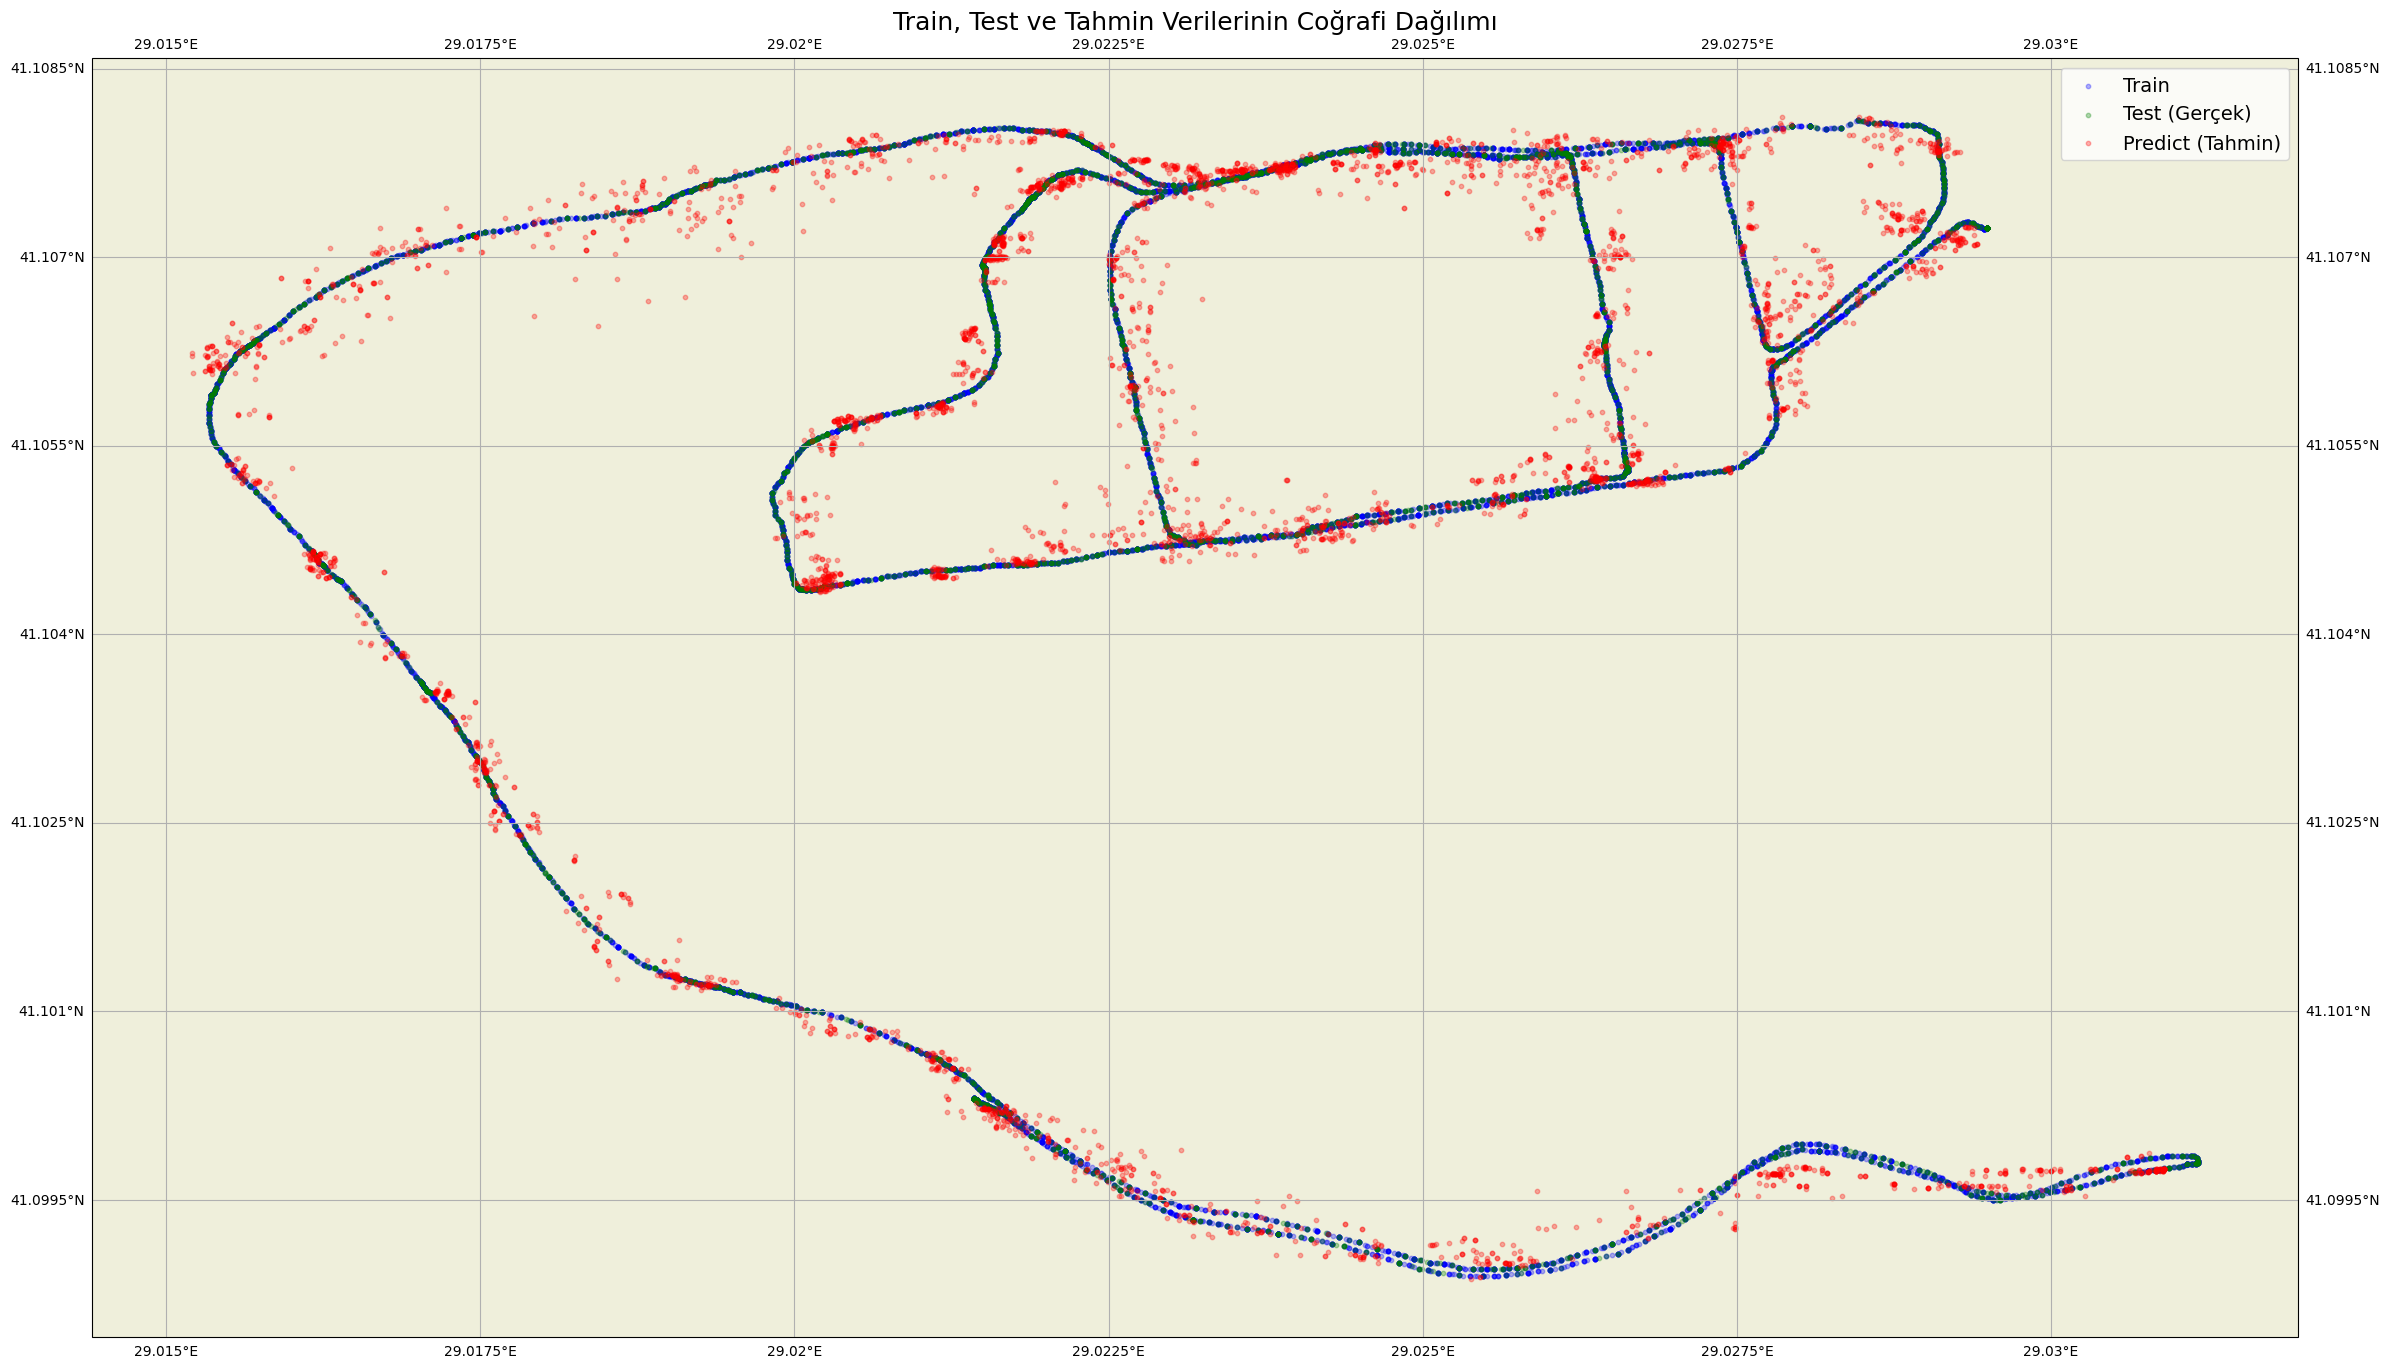

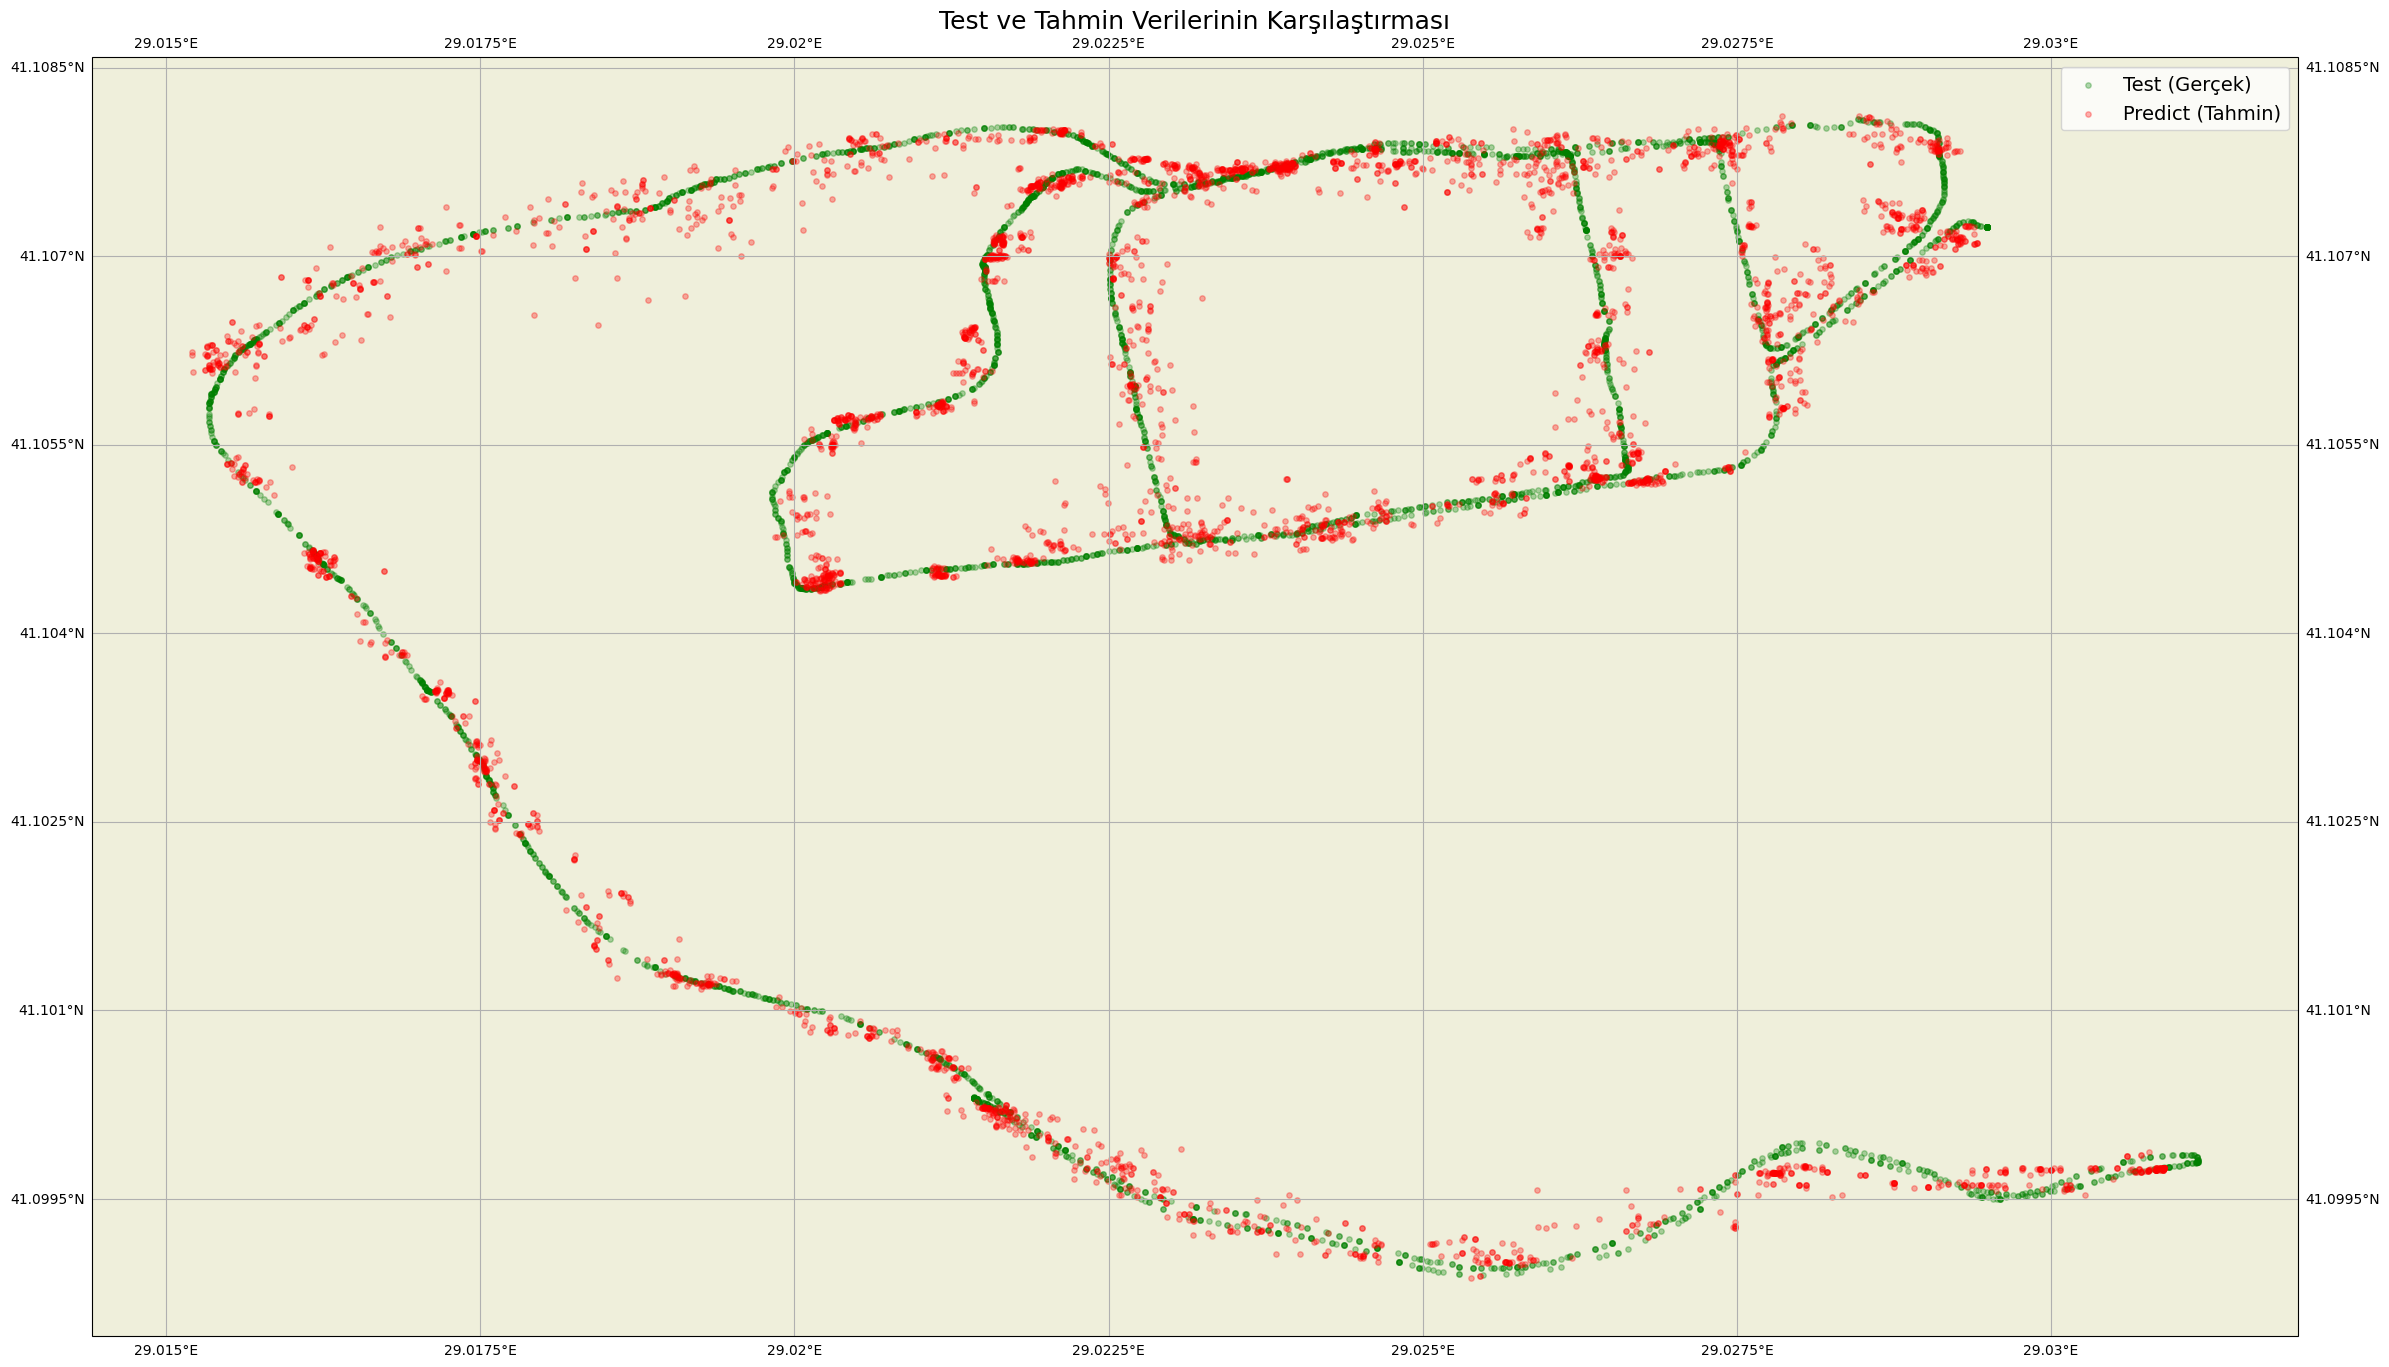

In [12]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

# Veri setlerini yükleme
train_loc = pd.read_csv(paths.train_df_path)
test_loc = pd.read_csv(paths.test_df_path)
predict_loc = pd.read_csv(paths.predictions_df_path)



# Harita oluştur
fig = plt.figure(figsize=(24, 16))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.gridlines(draw_labels=True)

# Veri setlerini farklı renklerle çizme
train_scatter = ax.scatter(
    train_loc["Longitude"], 
    train_loc["Latitude"],
    color='blue',
    s=10,
    alpha=0.3,
    label="Train"
)

test_scatter = ax.scatter(
    test_loc["Longitude"], 
    test_loc["Latitude"],
    color='green',
    s=10,
    alpha=0.3,
    label="Test (Gerçek)"
)

predict_scatter = ax.scatter(
    predict_loc["Longitude"], 
    predict_loc["Latitude"],
    color='red',
    s=10,
    alpha=0.3,
    label="Predict (Tahmin)"
)

# Başlık ve açıklamalar
ax.set_title("Train, Test ve Tahmin Verilerinin Coğrafi Dağılımı", fontsize=18)
ax.legend(fontsize=14)

# Belirli bir coğrafi bölgeye odaklanmak için (isteğe bağlı)
# ax.set_extent([min_long, max_long, min_lat, max_lat], crs=ccrs.PlateCarree())

plt.tight_layout()
plt.show()

# Sadece test ve tahmin verilerini karşılaştırmak için ikinci bir grafik
fig2 = plt.figure(figsize=(24, 16))
ax2 = fig2.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax2.add_feature(cfeature.LAND)
ax2.add_feature(cfeature.OCEAN)
ax2.add_feature(cfeature.COASTLINE)
ax2.add_feature(cfeature.BORDERS, linestyle=':')
ax2.gridlines(draw_labels=True)

# Sadece test ve tahmin verilerini göster
test_scatter = ax2.scatter(
    test_loc["Longitude"], 
    test_loc["Latitude"],
    color='green',
    s=15,
    alpha=0.3,
    label="Test (Gerçek)"
)

predict_scatter = ax2.scatter(
    predict_loc["Longitude"], 
    predict_loc["Latitude"],
    color='red',
    s=15,
    alpha=0.3,
    label="Predict (Tahmin)"
)

ax2.set_title("Test ve Tahmin Verilerinin Karşılaştırması", fontsize=18)
ax2.legend(fontsize=14)

plt.tight_layout()
plt.show()

In [13]:
def measure(lat1, lon1, lat2, lon2): # Haversine formülü ile iki nokta arasındaki mesafeyi hesaplar
    R = 6378.137  # Yerkürenin yarıçapı (km)
    dLat = math.radians(lat2 - lat1)
    dLon = math.radians(lon2 - lon1)
    
    a = math.sin(dLat / 2) ** 2 + \
        math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * \
        math.sin(dLon / 2) ** 2
    
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = R * c
    return d * 1000  # metre cinsinden mesafe


In [14]:
predict_loc["Distance"] = pd.concat([test_loc, predict_loc], axis=1, keys=["test", "predict"]).apply(
    lambda row: measure(row["test"]["Latitude"], row["test"]["Longitude"], 
                         row["predict"]["Latitude"], row["predict"]["Longitude"]), axis=1
)

In [15]:
predict_loc

,Longitude,Latitude,Distance
0,29.025396,41.105228,43.844710
1,29.025226,41.107927,16.335693
2,29.022683,41.107778,20.771000
3,29.026462,41.105372,15.251162
4,29.023145,41.107613,37.527376
...,...,...,...
4205,29.028260,41.106533,5.610268
4206,29.024136,41.099158,32.390057
4207,29.020104,41.104369,3.838616
4208,29.023399,41.105021,30.405731


C:\Users\osman\AppData\Local\Temp\ipykernel_4812\3162098717.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower left', fontsize=12)


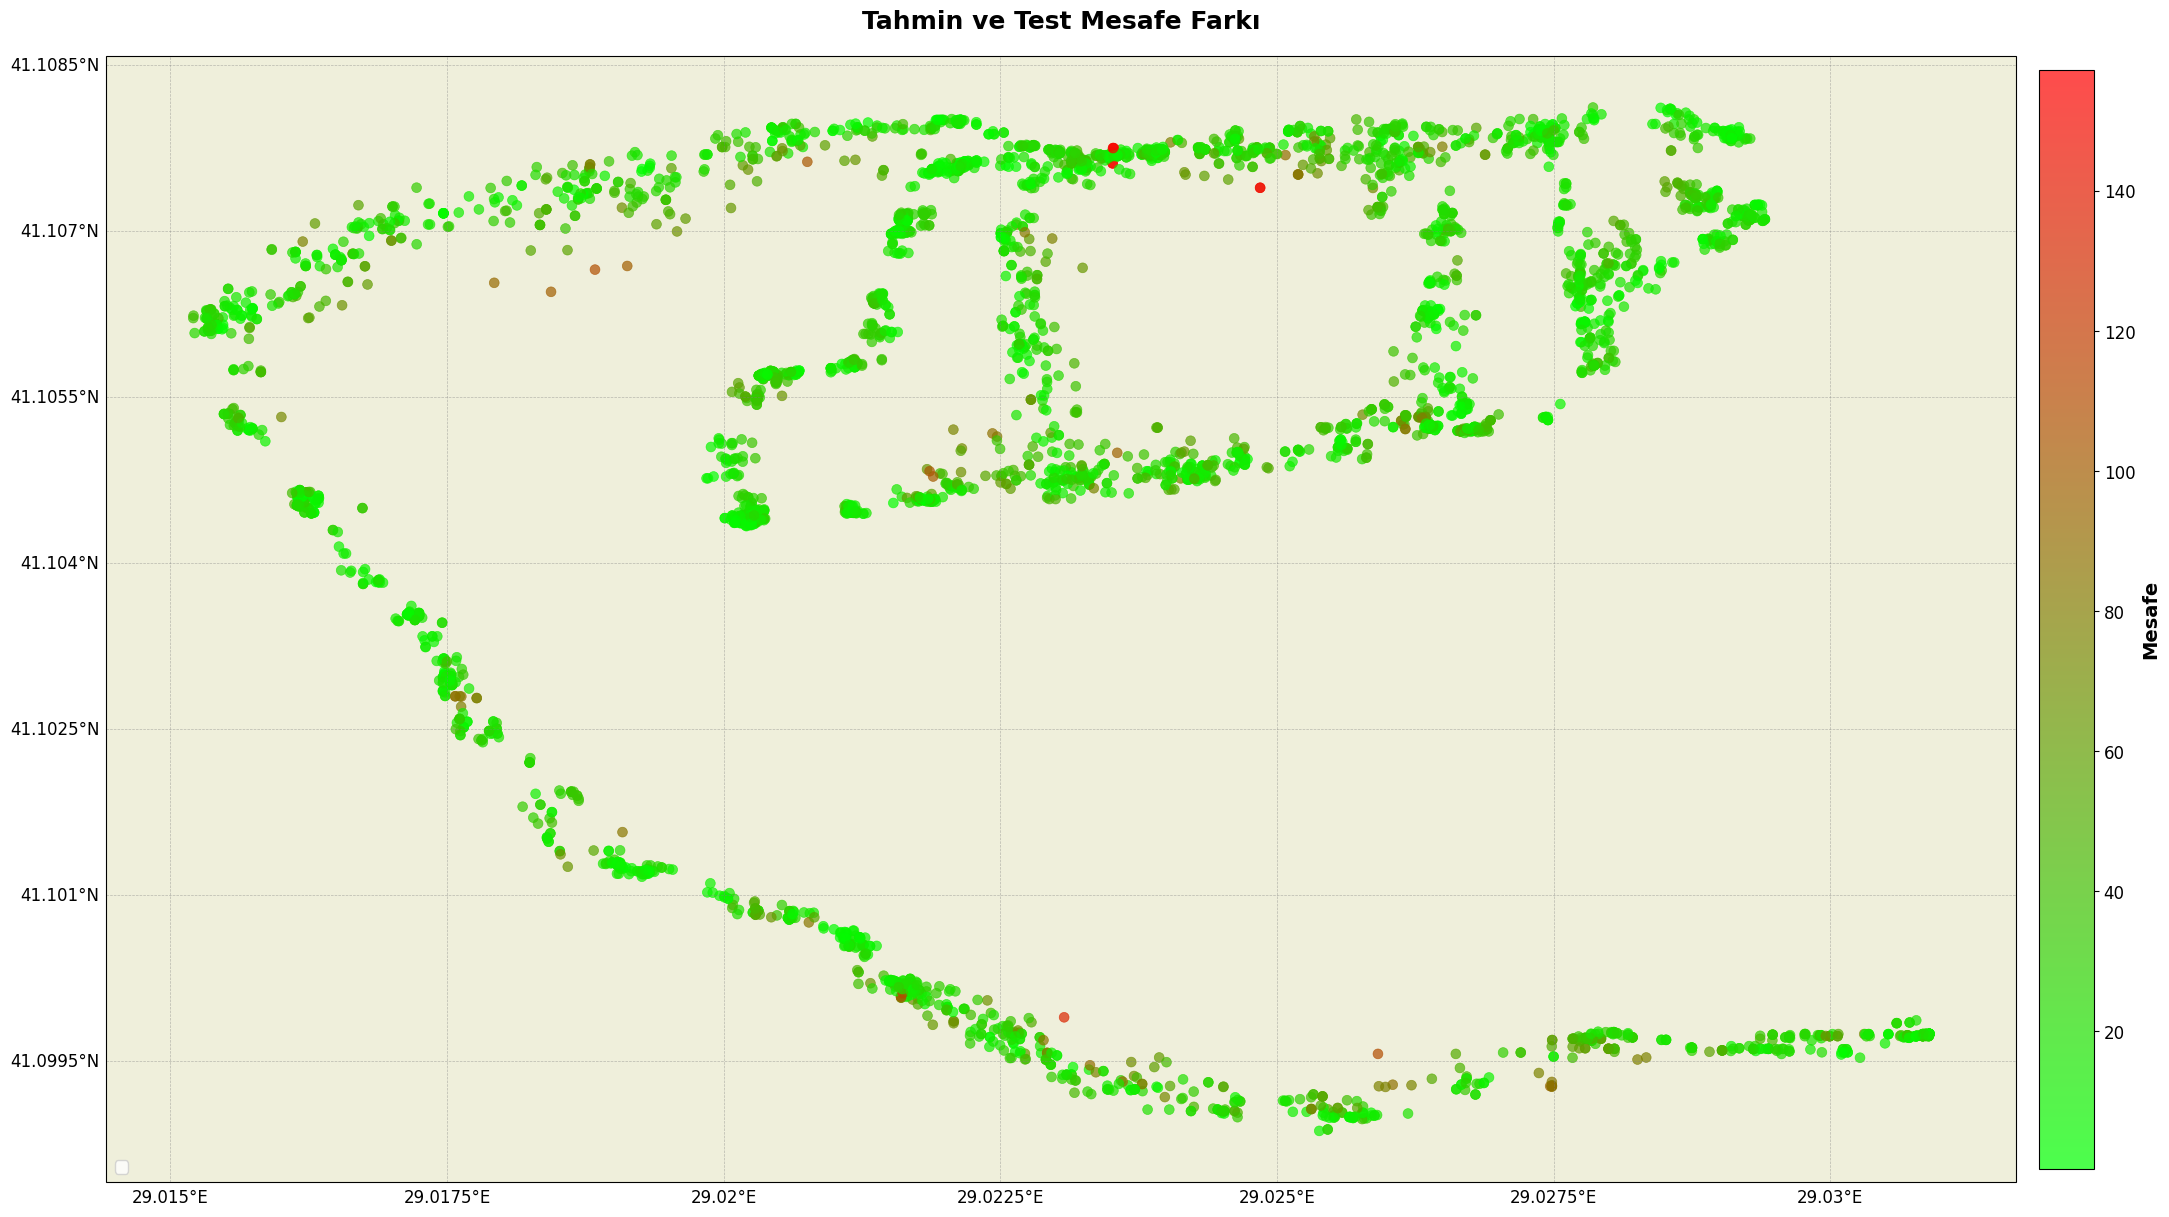

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.colors import LinearSegmentedColormap

# Daha büyük ve temiz görünümlü bir harita oluştur
fig = plt.figure(figsize=(24, 16))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)

# Izgara çizgilerini ekle
gridlines = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gridlines.top_labels = False
gridlines.right_labels = False
gridlines.xformatter = LONGITUDE_FORMATTER
gridlines.yformatter = LATITUDE_FORMATTER
gridlines.xlabel_style = {'size': 12}
gridlines.ylabel_style = {'size': 12}




colors = ["#00ff00","#ff0000"] 
cmap = LinearSegmentedColormap.from_list("red_green", colors)

# Ana scatter plot (zaman skalalı renkler)
scatter = ax.scatter(
    predict_loc["Longitude"],
    predict_loc["Latitude"],
    c=predict_loc["Distance"],
    cmap=cmap,
    alpha=0.7,
    s=50,  # Nokta boyutunu artır
    linewidths=0.5
)

# Renk çubuğu ekle ve özelleştir
cbar = plt.colorbar(scatter, ax=ax, pad=0.01, shrink=.7)
cbar.set_label('Mesafe', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

# Başlık ve lejant ekle
plt.title('Tahmin ve Test Mesafe Farkı', fontsize=18, fontweight='bold', pad=20)
plt.legend(loc='lower left', fontsize=12)

# Lejantı haritanın üstüne değil, dışına taşı
plt.tight_layout()
plt.show()

In [17]:
import geopandas as gpd

C:\Users\osman\AppData\Local\Temp\ipykernel_4812\3248036768.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower left', fontsize=12)


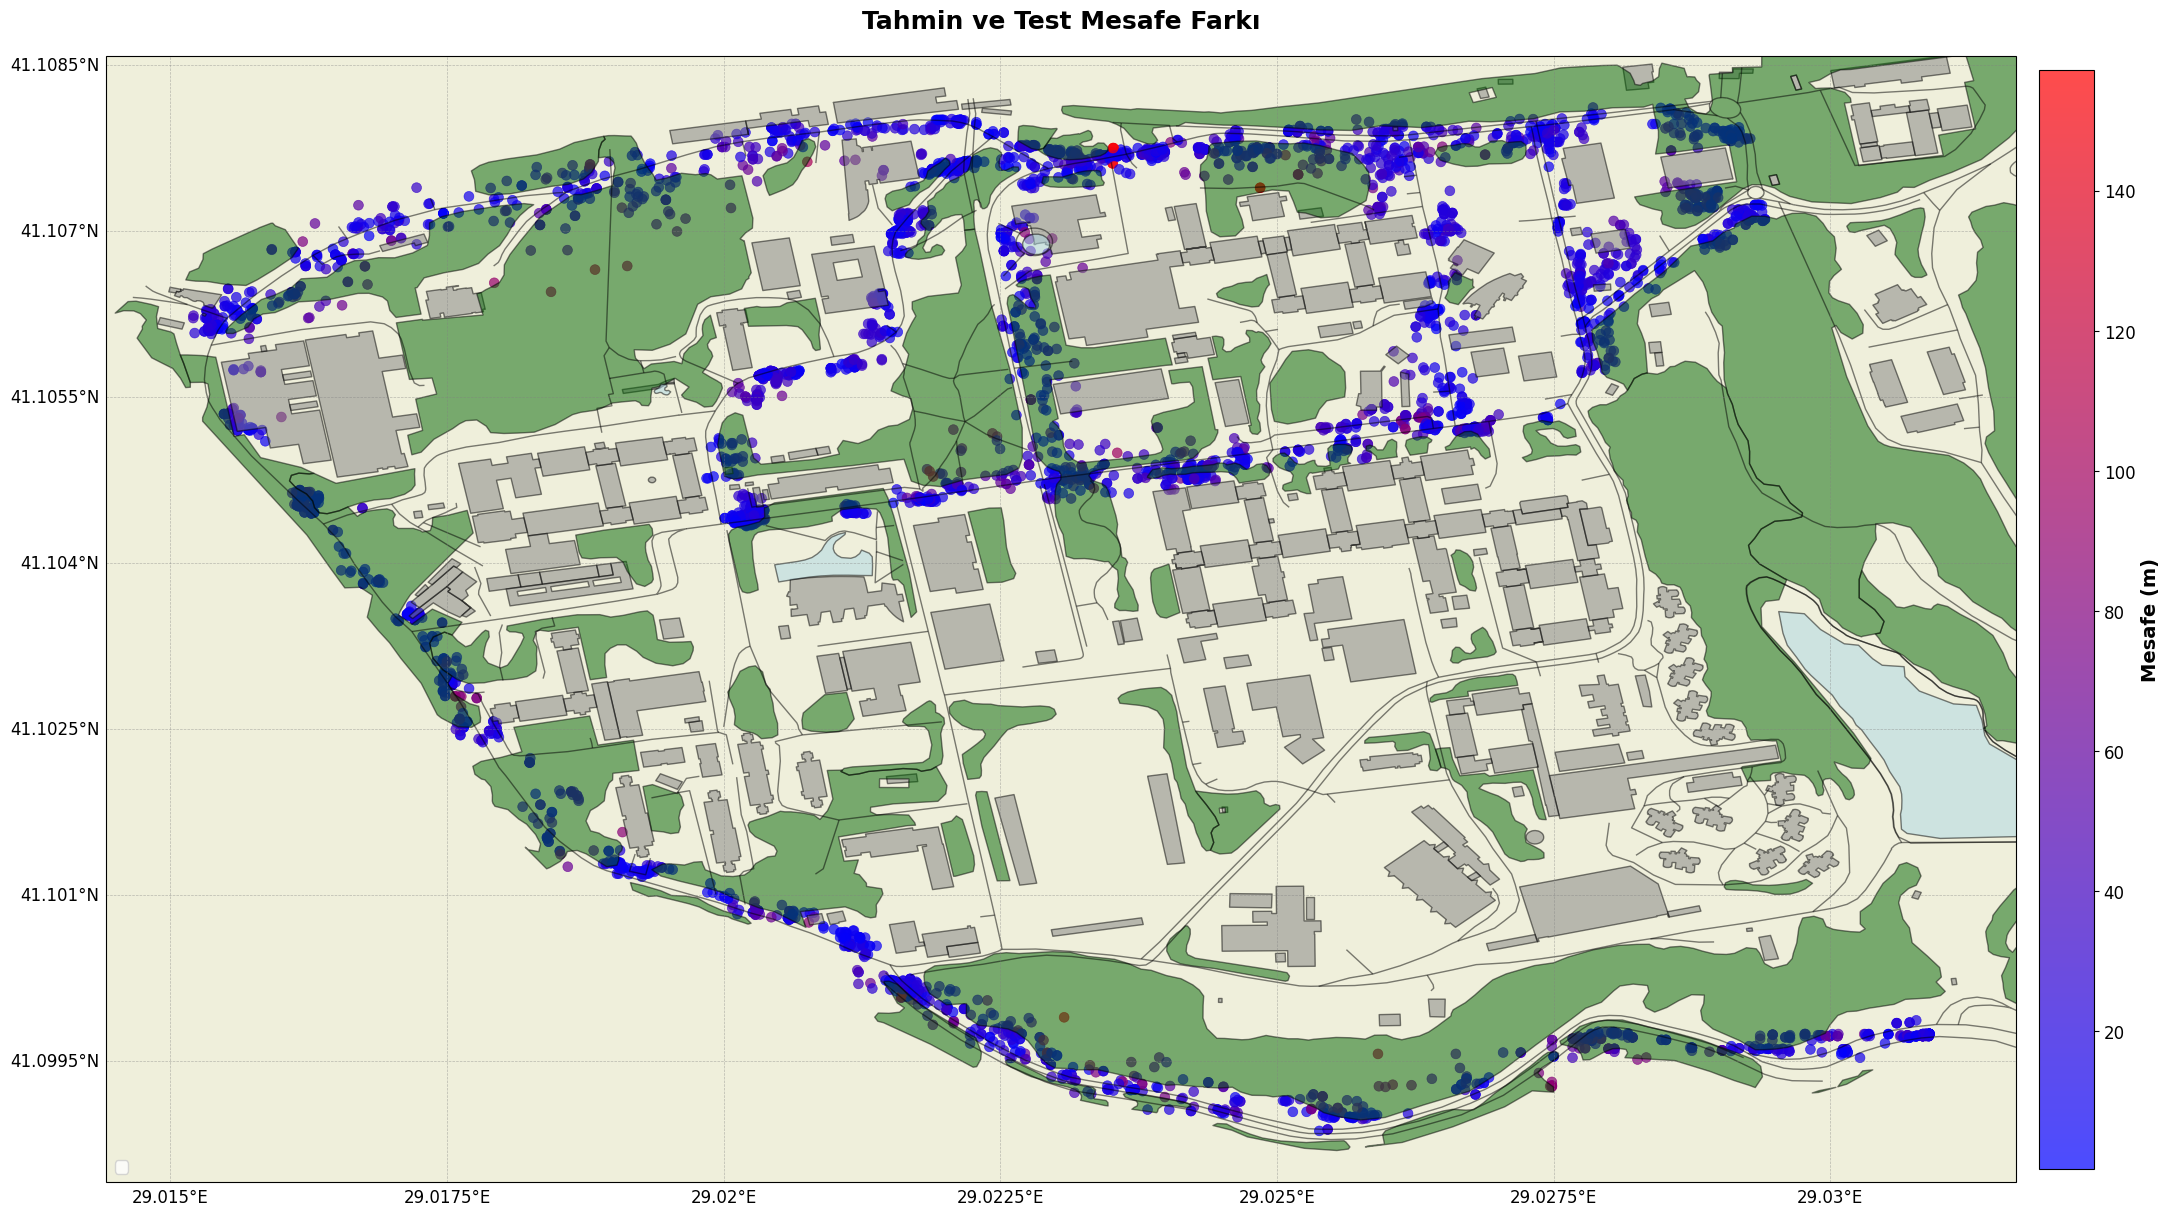

In [18]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.colors import LinearSegmentedColormap
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature

# Daha büyük ve temiz görünümlü bir harita oluştur
fig = plt.figure(figsize=(24, 16))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)

# ITU binalarının shapefile'ını ekleü
reader = shpreader.Reader(paths.build_path)
buildings = ShapelyFeature(reader.geometries(), ccrs.PlateCarree(),
                           edgecolor='black', facecolor='gray', alpha=0.5)
ax.add_feature(buildings)

reader = shpreader.Reader(paths.vege_path)
vegetations = ShapelyFeature(reader.geometries(), ccrs.PlateCarree(),
                           edgecolor='black', facecolor='DarkGreen', alpha=0.5)
ax.add_feature(vegetations)

reader = shpreader.Reader(paths.wathers_path)
wathers = ShapelyFeature(reader.geometries(), ccrs.PlateCarree(),
                           edgecolor='black', facecolor='LightBlue', alpha=0.5)
ax.add_feature(wathers)

reader = shpreader.Reader(paths.roads_path)
roads = ShapelyFeature(reader.geometries(), ccrs.PlateCarree(),
                           edgecolor='black', facecolor='none', alpha=0.5)
ax.add_feature(roads)

# Izgara çizgilerini ekle
gridlines = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gridlines.top_labels = False
gridlines.right_labels = False
gridlines.xformatter = LONGITUDE_FORMATTER
gridlines.yformatter = LATITUDE_FORMATTER
gridlines.xlabel_style = {'size': 12}
gridlines.ylabel_style = {'size': 12}

colors = ["#0000ff","#ff0000"] 
cmap = LinearSegmentedColormap.from_list("red_green", colors)

# Ana scatter plot (zaman skalalı renkler)
scatter = ax.scatter(
    predict_loc["Longitude"],
    predict_loc["Latitude"],
    c=predict_loc["Distance"],
    cmap=cmap,
    alpha=0.7,
    s=50,  # Nokta boyutunu artır
    linewidths=0.5
)

# Renk çubuğu ekle ve özelleştir
cbar = plt.colorbar(scatter, ax=ax, pad=0.01, shrink=.7)
cbar.set_label('Mesafe (m)', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

# Başlık ve lejant ekle
plt.title('Tahmin ve Test Mesafe Farkı', fontsize=18, fontweight='bold', pad=20)
plt.legend(loc='lower left', fontsize=12)

# Lejantı haritanın üstüne değil, dışına taşı
plt.tight_layout()
plt.show()

C:\Users\osman\AppData\Local\Temp\ipykernel_4812\653122588.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower left', fontsize=12)


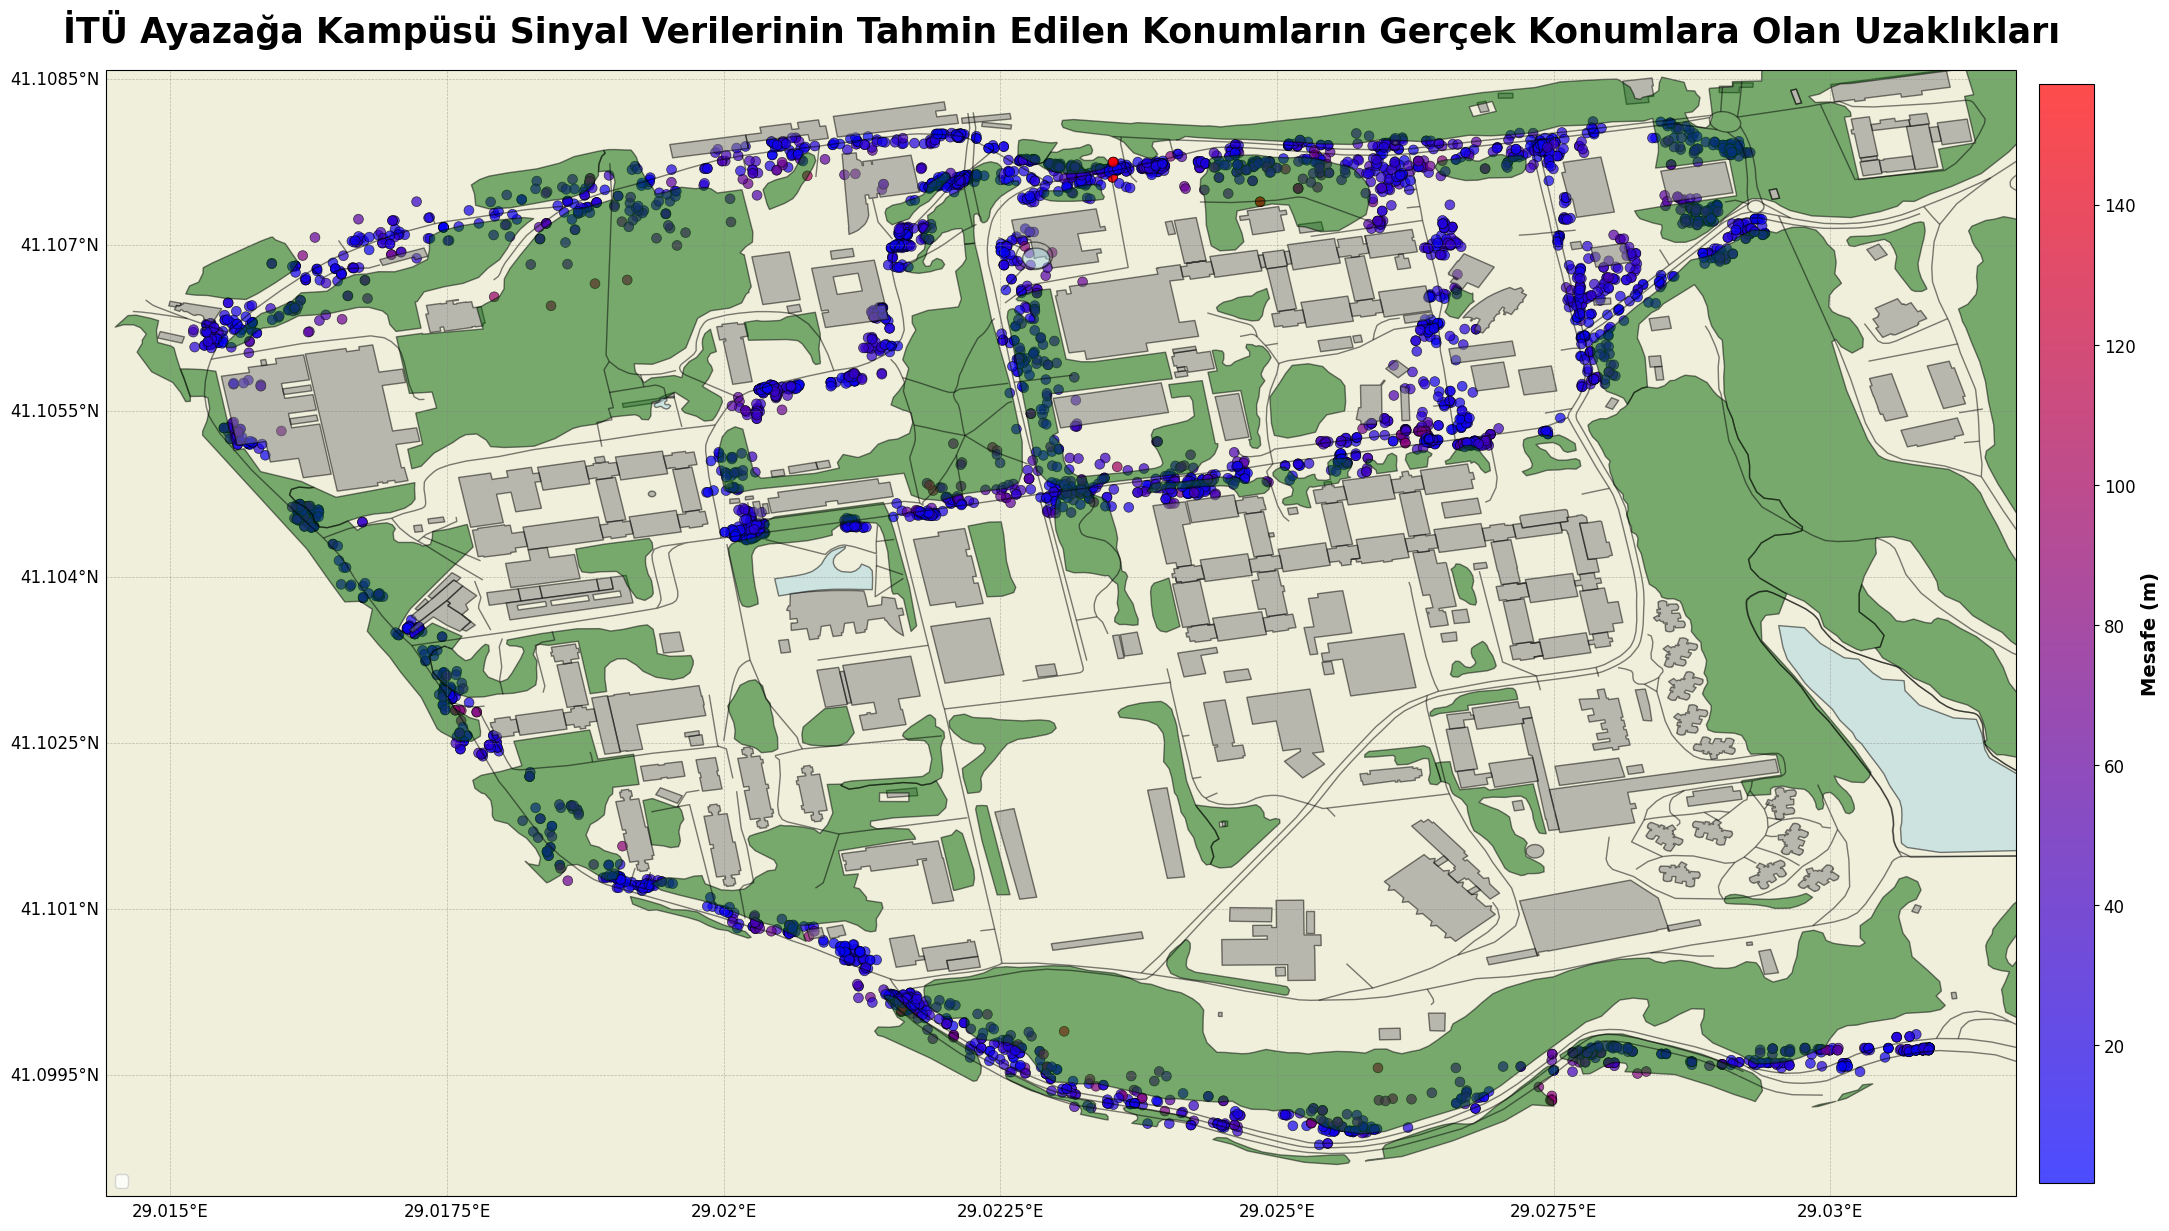

In [19]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.colors import LinearSegmentedColormap
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature

# Daha büyük ve temiz görünümlü bir harita oluştur
fig = plt.figure(figsize=(24, 16))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)

reader = shpreader.Reader(paths.build_path)
buildings = ShapelyFeature(reader.geometries(), ccrs.PlateCarree(),
                           edgecolor='black', facecolor='gray', alpha=0.5)
ax.add_feature(buildings)

reader = shpreader.Reader(paths.vege_path)
vegetations = ShapelyFeature(reader.geometries(), ccrs.PlateCarree(),
                           edgecolor='black', facecolor='DarkGreen', alpha=0.5)
ax.add_feature(vegetations)

reader = shpreader.Reader(paths.wathers_path)
wathers = ShapelyFeature(reader.geometries(), ccrs.PlateCarree(),
                           edgecolor='black', facecolor='LightBlue', alpha=0.5)
ax.add_feature(wathers)

reader = shpreader.Reader(paths.roads_path)
roads = ShapelyFeature(reader.geometries(), ccrs.PlateCarree(),
                           edgecolor='black', facecolor='none', alpha=0.5)
ax.add_feature(roads)

# Izgara çizgilerini ekle
gridlines = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gridlines.top_labels = False
gridlines.right_labels = False
gridlines.xformatter = LONGITUDE_FORMATTER
gridlines.yformatter = LATITUDE_FORMATTER
gridlines.xlabel_style = {'size': 12}
gridlines.ylabel_style = {'size': 12}

colors = ["#0000ff","#ff0000"] 
cmap = LinearSegmentedColormap.from_list("red_green", colors)

# Ana scatter plot (zaman skalalı renkler)
scatter = ax.scatter(
    predict_loc["Longitude"],
    predict_loc["Latitude"],
    c=predict_loc["Distance"],
    cmap=cmap,
    alpha=0.7,
    s=50,  # Nokta boyutunu artır
    linewidths=0.5,
    edgecolors='black'
)

# Renk çubuğu ekle ve özelleştir
cbar = plt.colorbar(scatter, ax=ax, pad=0.01, shrink=.7)
cbar.set_label('Mesafe (m)', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

# Başlık ve lejant ekle
plt.title('İTÜ Ayazağa Kampüsü Sinyal Verilerinin Tahmin Edilen Konumların Gerçek Konumlara Olan Uzaklıkları', fontsize=25, fontweight='bold', pad=20)
plt.legend(loc='lower left', fontsize=12)

# Lejantı haritanın üstüne değil, dışına taşı
plt.tight_layout()
plt.show()

In [20]:
full_data = pd.read_parquet(paths.parquet_data)

In [21]:
full_data

,Time,DL_NR_UE_RSRP_0,DL_NR_UE_RSRQ_0,DL_NR_UE_SINR_0,DL_NR_UE_Nbr_RSRP_0,DL_NR_UE_Nbr_RSRP_1,DL_NR_UE_Nbr_RSRP_2,DL_NR_UE_Nbr_RSRP_3,DL_NR_UE_Nbr_RSRP_4,DL_NR_UE_Nbr_RSRQ_0,...,UL_NR_UE_CCE_AggregationLev_0_LEVEL_4,UL_NR_UE_CCE_AggregationLev_0_LEVEL_8,DL_NR_UE_Modulation_Avg_DL_0_16QAM,DL_NR_UE_Modulation_Avg_DL_0_256QAM,DL_NR_UE_Modulation_Avg_DL_0_64QAM,DL_NR_UE_Modulation_Avg_DL_0_QPSK,UL_NR_UE_Modulation_Avg_DL_0_16QAM,UL_NR_UE_Modulation_Avg_DL_0_256QAM,UL_NR_UE_Modulation_Avg_DL_0_64QAM,UL_NR_UE_Modulation_Avg_DL_0_QPSK
index,,,,,,,,,,,,,,,,,,,,,
0,2025-03-14 12:14:32.955,-87.1,-11.2,7.3,-97.3,-88.6,-99.1,-120.6,-116.8,-16.3,...,False,False,False,True,False,False,False,True,False,False
1,2025-03-14 12:14:32.966,-87.1,-11.2,7.3,-97.3,-88.6,-99.1,-120.6,-116.8,-16.3,...,False,False,False,True,False,False,False,True,False,False
3,2025-03-14 12:14:33.135,-87.1,-11.2,7.3,-97.3,-88.6,-99.1,-120.6,-116.8,-16.3,...,False,False,False,True,False,False,False,True,False,False
4,2025-03-14 12:14:33.444,-87.1,-11.2,7.3,-97.3,-88.6,-99.1,-120.6,-116.8,-16.3,...,False,False,False,True,False,False,False,True,False,False
5,2025-03-14 12:14:33.499,-87.1,-11.2,7.3,-97.3,-88.6,-99.1,-120.6,-116.8,-16.3,...,False,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21045,2025-03-14 12:32:17.647,-120.3,-13.9,-1.7,-121.5,-108.1,-108.4,-121.5,-123.5,-15.8,...,False,True,False,False,False,True,False,False,False,True
21046,2025-03-14 12:32:17.649,-120.3,-13.9,-1.7,-121.5,-108.1,-108.4,-121.5,-123.5,-15.8,...,False,True,False,False,False,True,False,False,False,True
21047,2025-03-14 12:32:17.650,-120.3,-13.9,-1.7,-121.5,-108.1,-108.4,-121.5,-123.5,-15.8,...,False,True,False,False,False,True,False,False,False,True


C:\Users\osman\AppData\Local\Temp\ipykernel_4812\2807772385.py:17: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  time_ms = pd.to_datetime(full_data["Time"]).view('int64') // 10**6


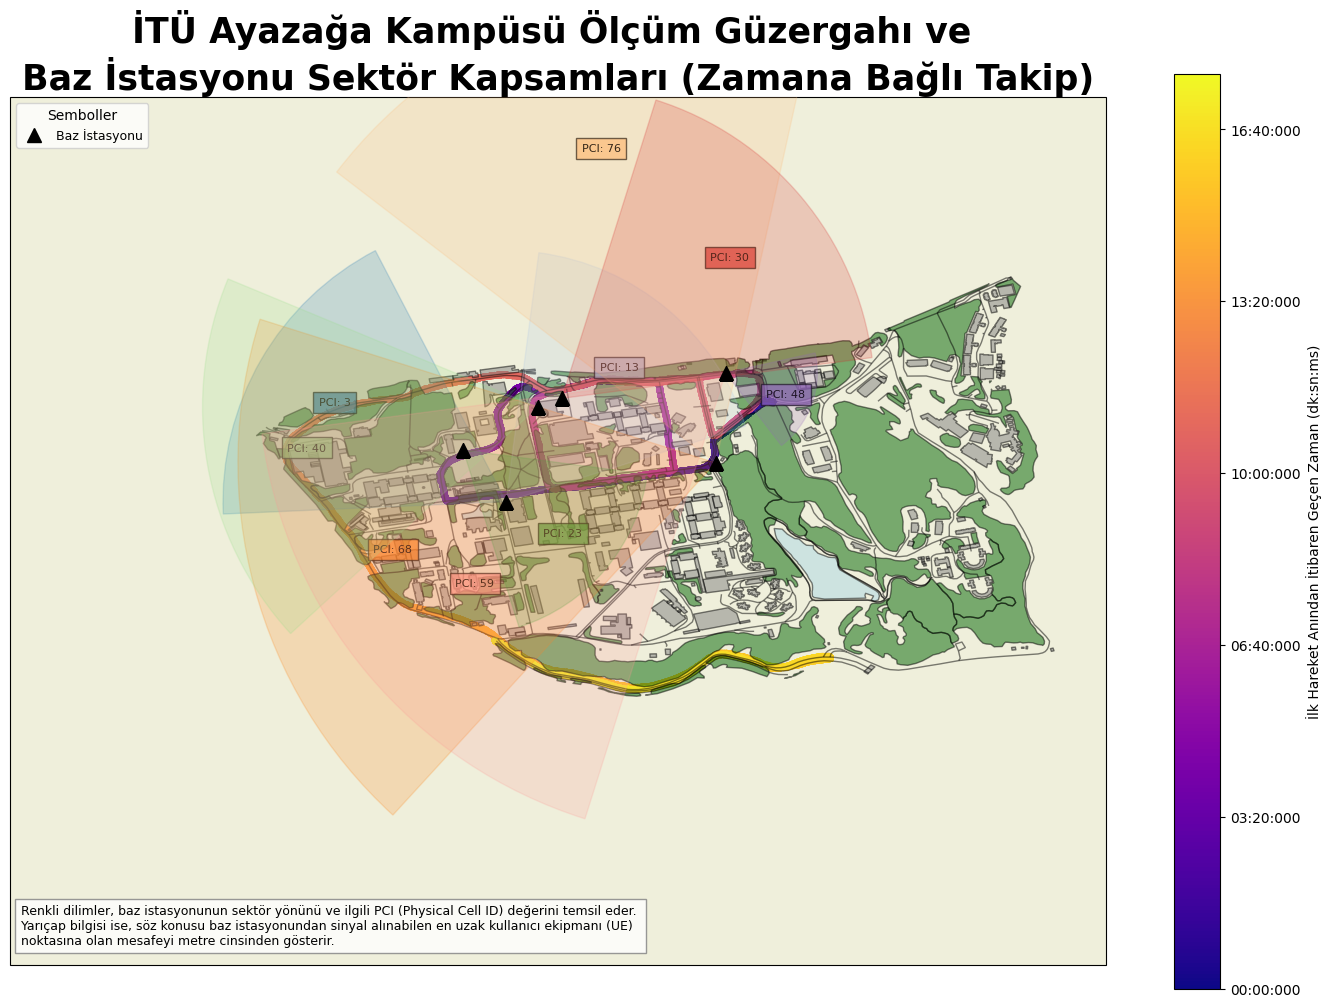

In [22]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.colors import LinearSegmentedColormap
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.patches import Wedge
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd

# Zamanı milisaniye cinsinden Unix formatına çevir
# 1. Zamanı milisaniye cinsinden al ve 0'dan başlat
time_ms = pd.to_datetime(full_data["Time"]).view('int64') // 10**6
time_numeric = time_ms - time_ms.min()  # Başlangıcı sıfırla


# Harita oluştur
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_title(
    "İTÜ Ayazağa Kampüsü Ölçüm Güzergahı ve \nBaz İstasyonu Sektör Kapsamları (Zamana Bağlı Takip)",
    fontsize=25,
    fontweight='bold'
)

ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)


for path, color, alpha in [
    (paths.build_path, 'gray', 0.5),
    (paths.vege_path, 'DarkGreen', 0.5),
    (paths.wathers_path, 'LightBlue', 0.5),
    (paths.roads_path, 'none', 0.5)
]:
    reader = shpreader.Reader(path)
    feature = ShapelyFeature(reader.geometries(), ccrs.PlateCarree(),
                             edgecolor='black', facecolor=color, alpha=alpha)
    ax.add_feature(feature)

# Haritayı ölçeklendir
buffer = 0.008
min_lon = min(bs_df["Longitude"].min(), full_data["Longitude"].min()) - buffer
max_lon = max(bs_df["Longitude"].max(), full_data["Longitude"].max()) + buffer
min_lat = min(bs_df["Latitude"].min(), full_data["Latitude"].min()) - buffer
max_lat = max(bs_df["Latitude"].max(), full_data["Latitude"].max()) + buffer
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

# Ana scatter plot (renk: zaman)
sc = ax.scatter(
    full_data["Longitude"],
    full_data["Latitude"],
    c=time_numeric,
    cmap="plasma",
    s=15,
)

# PCI renk haritası oluştur
pci_cmap = plt.cm.tab20(np.linspace(0, 1, 20))
pci_colors = dict()

# Baz istasyonları ve sektörlerini çiz
station_groups = bs_df.groupby(["Latitude", "Longitude"])
for (lat, lon), group in station_groups:
    ax.plot(lon, lat, 'k^', markersize=10, markeredgecolor='Black', zorder=10)
    for _, row in group.iterrows():
        azimuth = row["Azimuth [°]"]
        beamwidth = row["Horizontal Beamwidth [°]"]
        pci = row["PCI "]
        
        if pci not in pci_colors:
            pci_colors[pci] = pci_cmap[len(pci_colors) % 20]
        
        math_angle = (90 - azimuth) % 360
        start_angle = (math_angle - beamwidth / 2) % 360
        end_angle = (math_angle + beamwidth / 2) % 360
        coverage_radius = row["max_coverage"] / 100
        
        wedge = Wedge((lon, lat), coverage_radius, start_angle, end_angle,
                      alpha=0.2, color=pci_colors[pci], zorder=5)
        ax.add_patch(wedge)
        
        middle_angle_rad = np.radians(math_angle)
        dx = np.cos(middle_angle_rad) * coverage_radius * 0.7
        dy = np.sin(middle_angle_rad) * coverage_radius * 0.7
        
        ax.text(lon + dx, lat + dy, f"PCI: {int(pci)}", fontsize=8,
                ha='center', va='center', bbox=dict(facecolor=pci_colors[pci], alpha=0.7))

# 📌 Zaman biçimlendirmesi: dakika:saniye:milisaniye
def format_time_mms(x, pos=None):
    ms_total = int(x)
    minutes = (ms_total // 60000) % 60
    seconds = (ms_total // 1000) % 60
    milliseconds = ms_total % 1000
    return f"{minutes:02}:{seconds:02}:{milliseconds:03}"

# Renk çubuğu (colorbar)
cbar = plt.colorbar(sc, label="İlk Hareket Anından İtibaren Geçen Zaman (dk:sn:ms)")
cbar.ax.yaxis.set_major_formatter(FuncFormatter(format_time_mms))

# Lejant
station_marker = mlines.Line2D([], [], color='black', marker='^', linestyle='None',
                               markersize=10, label='Baz İstasyonu')
ax.legend(handles=[station_marker], loc='upper left', title='Semboller', fontsize=9, title_fontsize=10)

# Açıklama kutusu (PCI sektörü)
ax.text(
    0.01, 0.02,
    "Renkli dilimler, baz istasyonunun sektör yönünü ve ilgili PCI (Physical Cell ID) değerini temsil eder. \n"
    "Yarıçap bilgisi ise, söz konusu baz istasyonundan sinyal alınabilen en uzak kullanıcı ekipmanı (UE) \n"
    "noktasına olan mesafeyi metre cinsinden gösterir.",
    transform=ax.transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'),
    ha='left',
    va='bottom'
)

plt.tight_layout()
plt.show()


C:\Users\osman\AppData\Local\Temp\ipykernel_4812\3006701978.py:11: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  time_ms = pd.to_datetime(full_data["Time"]).view('int64') // 10**6


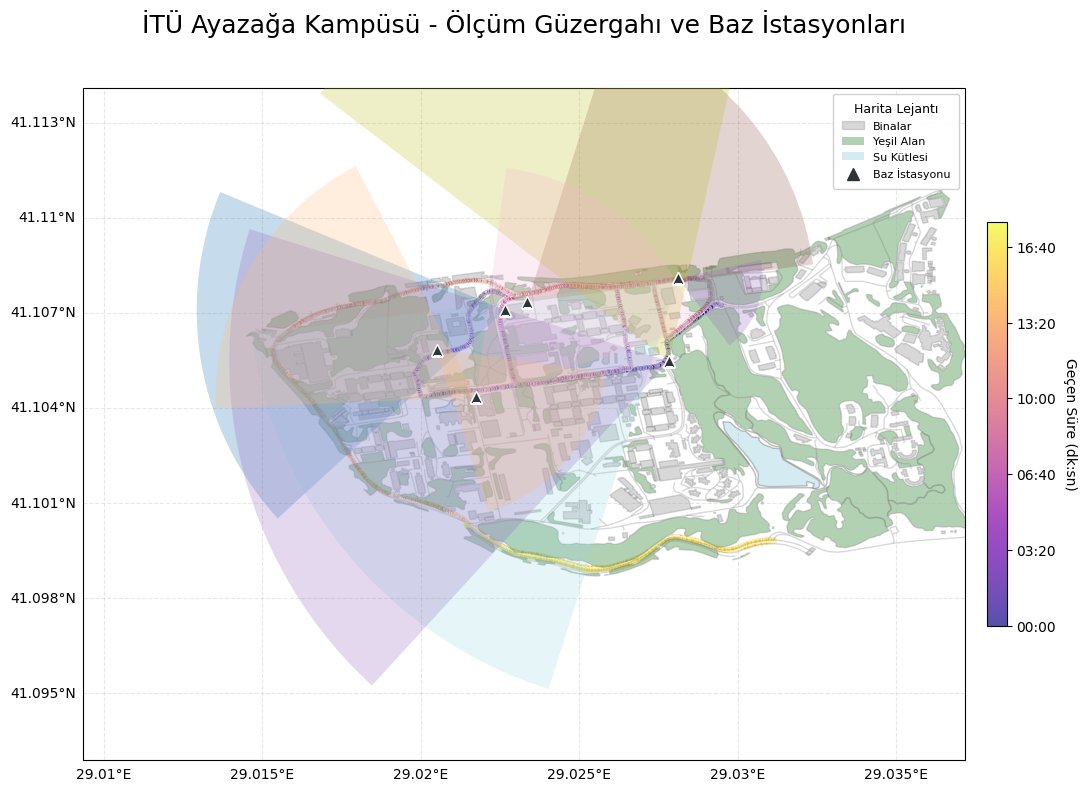

In [23]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.shapereader import Reader
from cartopy.feature import ShapelyFeature
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd

# Veri hazırlığı
time_ms = pd.to_datetime(full_data["Time"]).view('int64') // 10**6
time_numeric = time_ms - time_ms.min()

# Harita ayarları
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_title("İTÜ Ayazağa Kampüsü - Ölçüm Güzergahı ve Baz İstasyonları\n", 
            fontsize=18, pad=20)

# Shapefile yükleyici
def add_shapefile(path, color, alpha=0.3, edge='gray'):
    feature = ShapelyFeature(
        Reader(path).geometries(),
        ccrs.PlateCarree(),
        facecolor=color,
        edgecolor=edge,
        alpha=alpha
    )
    ax.add_feature(feature)

# Arka plan katmanları
add_shapefile(paths.build_path, 'gray')
add_shapefile(paths.vege_path, 'darkgreen')
add_shapefile(paths.wathers_path, 'lightblue', 0.5)
add_shapefile(paths.roads_path, 'none')

# Ölçüm noktaları
sc = ax.scatter(
    full_data["Longitude"],
    full_data["Latitude"],
    c=time_numeric,
    cmap="plasma",
    s=10,
    alpha=0.7,
    edgecolor='w',
    linewidth=0.3
)

# Baz istasyonları ve sektörler
pci_cmap = plt.get_cmap('tab20')
for _, row in bs_df.iterrows():
    lon, lat = row["Longitude"], row["Latitude"]
    
    # Baz istasyonu işaretleyici
    ax.plot(lon, lat, '^', color='#2d3436', markersize=8, 
           markeredgecolor='w', zorder=15)
    
    # Sektör çizimi
    color = pci_cmap(row["PCI "] % 20)
    wedge = Wedge(
        (lon, lat),
        row["max_coverage"]/100,
        90 - row["Azimuth [°]"] - row["Horizontal Beamwidth [°]"]/2,
        90 - row["Azimuth [°]"] + row["Horizontal Beamwidth [°]"]/2,
        facecolor=color,
        alpha=0.25,
        zorder=5
    )
    ax.add_patch(wedge)

# Renk çubuğu
def time_formatter(x, pos):
    ms = int(x)
    return f"{ms//60000:02}:{(ms//1000)%60:02}"
    
cbar = fig.colorbar(sc, ax=ax, orientation='vertical', pad=0.02, 
                   shrink=0.6, aspect=20)
cbar.set_label('Geçen Süre (dk:sn)', rotation=270, labelpad=15)
cbar.ax.yaxis.set_major_formatter(FuncFormatter(time_formatter))

# Lejant ve açıklamalar
legend_elements = [
    mpatches.Patch(facecolor='gray', alpha=0.3, edgecolor='gray', label='Binalar'),
    mpatches.Patch(facecolor='darkgreen', alpha=0.3, label='Yeşil Alan'),
    mpatches.Patch(facecolor='lightblue', alpha=0.5, label='Su Kütlesi'),
    mlines.Line2D([], [], color='#2d3436', marker='^', linestyle='None',
                 markersize=8, label='Baz İstasyonu')
]

ax.legend(
    handles=legend_elements,
    loc='upper right',
    frameon=True,
    framealpha=0.9,
    fontsize=8,
    title="Harita Lejantı",
    title_fontsize=9,
    borderpad=0.8,
    handletextpad=0.8
)

# Grid ve kenar süslemeleri
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.3)
gl.top_labels = gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Zoom ayarı
buffer = 0.006
ax.set_extent([
    full_data["Longitude"].min() - buffer,
    full_data["Longitude"].max() + buffer,
    full_data["Latitude"].min() - buffer,
    full_data["Latitude"].max() + buffer
])

plt.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.08)
plt.show()